# Module 1 · Embeddings — Homework 🏠
## Building a translator: seq2seq, encoder–decoder, and attention
# Student: Ricardo Torres López

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mago-cinv/course-template/blob/master/modules/01-embeddings/labs/homework/solution.ipynb)

This homework pairs with **Lesson 4** (sequence-to-sequence, the encoder–decoder architecture, teacher forcing, and encoder–decoder attention in Query/Key/Value form).

In the in-class labs you built *word* vectors and *document* vectors. Here you build something that **generates language**: an English → Spanish translator.

### How this homework works

**The machinery is given to you.** The parallel corpus, both vocabularies, the LSTM encoder–decoder, the attention mechanism, the training loop, greedy decoding, BLEU and the plotting helpers are all written, commented and *already run* below. You are **not** asked to implement `nn.LSTM` or re-derive softmax — that is plumbing, and plumbing is not the lesson.

**What you write is the investigation.** You get **two models that differ in exactly one thing** — one has attention, one doesn't — and six experiments (🔬 **C1**–**C6**) that ask you to take them apart: measure, plot, read the alignments, and defend a conclusion with numbers *you* produced.

Treat everything above the 🔬 sections as your **sandbox**: read it, run it, then take it apart.

### What you'll produce

Each 🔬 experiment ends with a markdown cell where you explain what you found and what it means — six written conclusions in total (C1–C6).

The code is a few lines of glue — the experiments just need to actually **run**, because your conclusions have to cite numbers *you* produced. Each experiment ends with a `✓` check so you know your run is in good shape.

**Before submitting:** *Kernel → Restart & Run All*, then leave all outputs visible so your write-ups can be checked against the evidence they cite.

Everything runs on **CPU** in roughly **16 minutes** end to end — about 6 min for the two models of §3, and about 10 min for the Assignment's upgrade kit at the very bottom.

In [1]:
# Setup — run me first (works on Colab AND locally)
# On Colab this installs the extra libraries; locally the course venv
# (.venv, environment/requirements.txt) already has everything.
import sys

if "google.colab" in sys.modules:
    %pip install -q datasets transformers sentencepiece sacremoses

print("Setup OK — Python", sys.version.split()[0])

Setup OK — Python 3.11.13


In [2]:
# Imports + seeds — one reseed helper, called before EVERY model build so the
# two models start from identical weights and the comparison is fair.
import math, os, random, re, time
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn

SEED = 0
PAD, SOS, EOS, UNK = 0, 1, 2, 3      # reserved token ids, shared by both vocabularies
MAX_LEN = 20                          # longest source/target sentence we keep (in tokens)

def seed_all(s=SEED):
    random.seed(s); np.random.seed(s); torch.manual_seed(s)

seed_all()
torch.set_num_threads(max(1, (os.cpu_count() or 4) // 2))   # keep CPU use polite on shared machines
print("torch", torch.__version__, "| threads:", torch.get_num_threads())

torch 2.12.1+cpu | threads: 6


## 1 · The data (provided)

**Tatoeba** English→Spanish sentence pairs — short, human-written, human-translated sentences
(`Let's go` → `Vamos`), which is exactly the regime a small model can actually learn.

We keep pairs where **both** sides are 1–20 tokens, shuffle with a fixed seed, and split off a
held-out test set the models never train on.

In [3]:
from datasets import load_dataset

def tok(s):
    """Lowercase word tokenizer. Keeps apostrophes together ("let's" is ONE token) and
    splits punctuation off, including the Spanish opening marks ¿ and ¡."""
    return re.findall(r"[a-záéíóúüñ]+(?:'[a-z]+)?|[0-9]+|[¿?¡!.,;:]", s.lower())

t0 = time.time()
raw = load_dataset("ageron/tatoeba_mt_train", split="validation")   # eng→spa Tatoeba pairs

pairs = []
for r in raw:
    en, es = tok(r["source_text"]), tok(r["target_text"])
    if 1 <= len(en) <= MAX_LEN and 1 <= len(es) <= MAX_LEN:
        pairs.append((en, es))

seed_all()
random.shuffle(pairs)

# Tatoeba skews heavily SHORT (6-8 tokens is the mode; 17-20 tokens is <2% of the corpus), so a
# plain random test split would starve the long buckets C3 needs. We reserve up to 250 sentences
# PER LENGTH BUCKET for the test set first, then shuffle it so the general-purpose eval sets
# (C1, C6) stay a representative length mix rather than accidentally all-short.
LEN_BUCKETS = [(3, 5), (6, 8), (9, 12), (13, 16), (17, 20)]
TEST_PER_BUCKET = 250

by_len = {}
for i, (en, _) in enumerate(pairs):
    by_len.setdefault(len(en), []).append(i)

test_idx = set()
for lo, hi in LEN_BUCKETS:
    idxs = [i for L in range(lo, hi + 1) for i in by_len.get(L, [])]
    test_idx.update(idxs[:TEST_PER_BUCKET])

test_pairs = [pairs[i] for i in sorted(test_idx)]
seed_all()
random.shuffle(test_pairs)
train_pairs = [p for i, p in enumerate(pairs) if i not in test_idx][:45000]

print(f"{len(pairs):,} usable pairs (1-{MAX_LEN} tokens)  ->  "
      f"{len(train_pairs):,} train / {len(test_pairs):,} held-out test   ({time.time()-t0:.0f}s)")
print("test set covers", len(LEN_BUCKETS), "length buckets, up to", TEST_PER_BUCKET, "sentences each:")
for lo, hi in LEN_BUCKETS:
    n = sum(1 for a, _ in test_pairs if lo <= len(a) <= hi)
    print(f"   len {lo:2d}-{hi:2d}: {n} test sentences")
print("median source length (train):", int(np.median([len(a) for a, _ in train_pairs])), "tokens")
print()
for en, es in train_pairs[:4]:
    print(f"   {' '.join(en):42s} ->  {' '.join(es)}")

194,189 usable pairs (1-20 tokens)  ->  45,000 train / 1,250 held-out test   (39s)
test set covers 5 length buckets, up to 250 sentences each:
   len  3- 5: 250 test sentences
   len  6- 8: 250 test sentences
   len  9-12: 250 test sentences
   len 13-16: 250 test sentences
   len 17-20: 250 test sentences
median source length (train): 7 tokens

   i was about to go to bed when the phone rang . ->  me disponía a irme a la cama cuando sonó el teléfono .
   tom is so good at this .                   ->  tom es tan bueno para esto .
   how do you tell them apart ?               ->  ¿ cómo podéis distinguirlas ?
   the comparison is apt .                    ->  la comparación es apropiada .


In [4]:
# Two INDEPENDENT vocabularies — one per language (lesson 4: two embedding layers)
def build_vocab(seqs, max_words):
    counts = Counter(t for s in seqs for t in s)
    itos = ["<pad>", "<sos>", "<eos>", "<unk>"] + [w for w, _ in counts.most_common(max_words)]
    return itos, {w: i for i, w in enumerate(itos)}

en_itos, en_stoi = build_vocab([a for a, _ in train_pairs], 6000)
es_itos, es_stoi = build_vocab([b for _, b in train_pairs], 6000)

def enc_src(words):  return [en_stoi.get(t, UNK) for t in words][:MAX_LEN]
def enc_tgt(words):  return [SOS] + [es_stoi.get(t, UNK) for t in words][:MAX_LEN] + [EOS]
def pad_to(batch, n): return torch.tensor([x + [PAD] * (n - len(x)) for x in batch])

def make_tensors(prs):
    X = pad_to([enc_src(a) for a, _ in prs], MAX_LEN)          # (N, MAX_LEN)
    Y = pad_to([enc_tgt(b) for _, b in prs], MAX_LEN + 2)      # (N, MAX_LEN+2) — room for <sos>/<eos>
    return X, Y

Xtr, Ytr = make_tensors(train_pairs)
Xte, Yte = make_tensors(test_pairs)

print(f"English vocab {len(en_itos):,}   Spanish vocab {len(es_itos):,}")
print(f"source tensor {tuple(Xtr.shape)}   target tensor {tuple(Ytr.shape)}")
print("\nEncoded example:")
print("  ", ' '.join(train_pairs[0][0]), "->", enc_src(train_pairs[0][0]))
print("  ", ' '.join(train_pairs[0][1]), "->", enc_tgt(train_pairs[0][1]), "  (<sos> ... <eos>)")

English vocab 6,004   Spanish vocab 6,004
source tensor (45000, 20)   target tensor (45000, 22)

Encoded example:
   i was about to go to bed when the phone rang . -> [6, 20, 63, 7, 53, 7, 280, 72, 5, 462, 1402, 4]
   me disponía a irme a la cama cuando sonó el teléfono . -> [1, 18, 3, 9, 777, 9, 7, 308, 73, 1244, 10, 320, 4, 2]   (<sos> ... <eos>)


## 2 · Your toolkit (provided)

Everything below is written and working. **This is the sandbox** — C1–C6 are built entirely from these.

| Tool | What it gives you |
|---|---|
| `Seq2Seq(..., attention=True/False)` | the model — the flag is the **only** difference between the two |
| `train_model(model, epochs=…, tf_ratio=…)` | the training loop; `tf_ratio` is **C4's knob** (1.0 = full teacher forcing) |
| `translate(model, sentence)` | greedy decoding → the Spanish words |
| `translate(..., return_attention=True)` | also returns the $\alpha$ matrix — **C2's instrument** |
| `corpus_bleu(hyps, refs)` / `evaluate_bleu(model, pairs)` | the quality metric |
| `plot_heatmap(...)` | draws an alignment heatmap — **C2's plot** |
| `token_accuracy(model, X, Y, mode=…)` | teacher-forced vs. free-running accuracy — **C4's instrument** |
| `decode_trace(model, sentence)` | per-step top-k candidates and margins — **C5's instrument** |
| `by_length(pairs, lo, hi)` | filter the test set by source length — **C3's knob** |

In [5]:
# ══ TOOLKIT (part 1: the model) ══ provided; read it, then use it
class Seq2Seq(nn.Module):
    """LSTM encoder-decoder, with dot-product (Luong) attention optionally switched on.

    attention=False -> classic seq2seq (Lesson 4, Parts II-III): the decoder sees the source
                       ONLY through the encoder's final (h, c) — the context vector, eq. (2).
    attention=True  -> the decoder ALSO attends over every encoder state at every output
                       step (Lesson 4, eq. 4). Here W_Q = W_K = W_V = I, so the query is the
                       decoder state itself and keys = values = the encoder states.
    """
    def __init__(self, n_src, n_tgt, d=256, attention=True):
        super().__init__()
        self.attention = attention
        self.emb_src = nn.Embedding(n_src, d, padding_idx=PAD)   # English embeddings
        self.emb_tgt = nn.Embedding(n_tgt, d, padding_idx=PAD)   # Spanish embeddings
        self.encoder = nn.LSTM(d, d, batch_first=True)
        self.decoder = nn.LSTM(d, d, batch_first=True)
        self.combine = nn.Linear(2 * d, d) if attention else None
        self.out     = nn.Linear(d, n_tgt)                       # one logit per Spanish word

    def encode(self, x):
        """Run the encoder. Returns ALL states H (needed by attention) and the final
        (h, c) — which IS the context vector of eq. (2)."""
        H, (h, c) = self.encoder(self.emb_src(x))
        return H, (h, c)

    def decode_step(self, y_in, state, H, src_mask):
        """One (or several) decoder steps. Returns logits, the new state, and the
        attention weights alpha (None when attention is off)."""
        O, state = self.decoder(self.emb_tgt(y_in), state)
        if not self.attention:
            return self.out(O), state, None
        scores = O @ H.transpose(1, 2)                       # (B, Ty, Tx)  <- q · k
        scores = scores.masked_fill(src_mask.unsqueeze(1), -1e9)   # never attend to <pad>
        alpha  = scores.softmax(-1)                          # <- softmax, rows sum to 1
        ctx    = alpha @ H                                   # <- weighted sum of values
        feat   = torch.tanh(self.combine(torch.cat([O, ctx], -1)))
        return self.out(feat), state, alpha

    def forward(self, x, y_in):
        H, state = self.encode(x)
        logits, _, alpha = self.decode_step(y_in, state, H, x == PAD)
        return logits, alpha

def count_params(m): return sum(p.numel() for p in m.parameters())

In [6]:
# ══ TOOLKIT (part 2: training) ══ provided
def train_model(model, epochs=8, lr=2e-3, bs=128, tf_ratio=1.0, log=True):
    """Standard training loop. tf_ratio = probability of feeding the CORRECT previous word
    (teacher forcing). tf_ratio=1.0 is full teacher forcing and uses the fast batched path;
    anything lower runs the slower step-by-step path (scheduled sampling) — C4's knob."""
    opt = torch.optim.Adam(model.parameters(), lr)
    lossf = nn.CrossEntropyLoss(ignore_index=PAD)
    history = []
    for ep in range(epochs):
        model.train()
        perm = torch.randperm(len(Xtr)); total = nb = 0
        for i in range(0, len(Xtr), bs):
            idx = perm[i:i + bs]; x, y = Xtr[idx], Ytr[idx]
            if tf_ratio >= 1.0:
                logits, _ = model(x, y[:, :-1])
                loss = lossf(logits.reshape(-1, logits.size(-1)), y[:, 1:].reshape(-1))
            else:
                loss = _scheduled_sampling_loss(model, x, y, lossf, tf_ratio)
            opt.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step(); total += loss.item(); nb += 1
        history.append(total / nb)
        if log: print(f"   epoch {ep+1}/{epochs}: loss {total/nb:.3f}")
    return history

def _scheduled_sampling_loss(model, x, y, lossf, tf_ratio):
    H, state = model.encode(x); src_mask = x == PAD
    inp, all_logits = y[:, :1], []
    for t in range(y.size(1) - 1):
        lg, state, _ = model.decode_step(inp, state, H, src_mask)
        all_logits.append(lg)
        inp = y[:, t+1:t+2] if random.random() < tf_ratio else lg.argmax(-1).detach()
    logits = torch.cat(all_logits, 1)
    return lossf(logits.reshape(-1, logits.size(-1)), y[:, 1:].reshape(-1))

In [7]:
# ══ TOOLKIT (part 3: inference, metrics, plots) ══ provided
@torch.no_grad()
def translate(model, sentence, max_out=MAX_LEN + 2, return_attention=False):
    """Greedy decoding: <sos> -> word -> feed it back -> ... -> <eos> (Lesson 4, Part III)."""
    model.eval()
    src_words = tok(sentence) if isinstance(sentence, str) else list(sentence)
    x = pad_to([enc_src(src_words)], MAX_LEN)
    H, state = model.encode(x); src_mask = x == PAD
    inp = torch.tensor([[SOS]]); words, attns = [], []
    for _ in range(max_out):
        lg, state, alpha = model.decode_step(inp, state, H, src_mask)
        nxt = lg[0, -1].argmax().item()
        if nxt == EOS: break
        words.append(es_itos[nxt])
        if alpha is not None: attns.append(alpha[0, -1, :len(src_words)].tolist())
        inp = torch.tensor([[nxt]])
    if return_attention:
        return words, (np.array(attns) if attns else None), src_words
    return words

def _ngrams(seq, n): return Counter(tuple(seq[i:i+n]) for i in range(len(seq) - n + 1))

def corpus_bleu(hyps, refs, maxn=4):
    """Corpus BLEU-4 with brevity penalty. BLEU = BiLingual Evaluation Understudy, the standard
    machine-translation quality metric: modified n-gram precision (1..4 tokens) of the hypothesis
    against the reference, geometric-averaged across n, then penalized if the hypothesis is
    shorter than the reference (the brevity penalty). 0 = no overlap, 100 = identical to the
    reference."""
    num = [0]*maxn; den = [0]*maxn; hlen = rlen = 0
    for h, r in zip(hyps, refs):
        hlen += len(h); rlen += len(r)
        for n in range(1, maxn+1):
            hn, rn = _ngrams(h, n), _ngrams(r, n)
            den[n-1] += max(0, len(h) - n + 1)
            num[n-1] += sum(min(c, rn[g]) for g, c in hn.items())
    if min(num) == 0: return 0.0     # some n-gram order never matched (tiny samples do this)
    logp = sum(math.log(num[i]/den[i]) for i in range(maxn)) / maxn
    bp = 1.0 if hlen > rlen else math.exp(1 - rlen / max(hlen, 1))
    return 100 * bp * math.exp(logp)

def evaluate_bleu(model, prs):
    return corpus_bleu([translate(model, a) for a, _ in prs], [b for _, b in prs])

def by_length(prs, lo, hi):
    """Test pairs whose SOURCE sentence has between lo and hi tokens — C3's knob."""
    return [p for p in prs if lo <= len(p[0]) <= hi]

def plot_heatmap(alpha, src_words, tgt_words, ax=None, title=None):
    """Alignment heatmap: rows = generated Spanish words, columns = source English words."""
    if ax is None: _, ax = plt.subplots(figsize=(1 + 0.75*len(src_words), 1 + 0.5*len(tgt_words)))
    im = ax.imshow(alpha, cmap="Blues", vmin=0, vmax=1, aspect="auto")
    ax.set_xticks(range(len(src_words))); ax.set_xticklabels(src_words, rotation=45, ha="right")
    ax.set_yticks(range(len(tgt_words))); ax.set_yticklabels(tgt_words)
    ax.set_xlabel("source (English)"); ax.set_ylabel("generated (Spanish)")
    if title: ax.set_title(title, fontsize=10)
    return im

@torch.no_grad()
def token_accuracy(model, X, Y, mode="teacher"):
    """Next-token accuracy on the SAME data under two regimes — C4's instrument.
    mode="teacher": feed the correct previous word (what training does).
    mode="free":    feed the model's own previous prediction (what inference does)."""
    model.eval()
    H, state = model.encode(X); src_mask = X == PAD
    correct = total = 0; inp = Y[:, :1]
    for t in range(Y.size(1) - 1):
        lg, state, _ = model.decode_step(inp, state, H, src_mask)
        pred, gold = lg[:, -1].argmax(-1), Y[:, t+1]
        mask = gold != PAD
        correct += ((pred == gold) & mask).sum().item(); total += mask.sum().item()
        inp = (gold if mode == "teacher" else pred).unsqueeze(1)
    return correct / total

@torch.no_grad()
def decode_trace(model, sentence, topk=3, max_out=MAX_LEN + 2):
    """Replay greedy decoding and record, at every step, the top-k candidates and their
    probabilities plus the margin between #1 and #2 — C5's instrument."""
    model.eval()
    sw = tok(sentence)
    x = pad_to([enc_src(sw)], MAX_LEN); H, state = model.encode(x); src_mask = x == PAD
    inp = torch.tensor([[SOS]]); rows = []
    for _ in range(max_out):
        lg, state, _ = model.decode_step(inp, state, H, src_mask)
        p = lg[0, -1].softmax(-1); vals, idx = p.topk(topk)
        chosen = idx[0].item()
        rows.append({"chosen": es_itos[chosen],
                     "margin": round((vals[0] - vals[1]).item(), 3),
                     "top": [(es_itos[i], round(v.item(), 3)) for v, i in zip(vals, idx)]})
        if chosen == EOS: break
        inp = torch.tensor([[chosen]])
    return sw, rows

print("toolkit ready — 10 helpers loaded")

toolkit ready — 10 helpers loaded


## 3 · The two models (provided, trained here)

Two models, **identical in every way except one flag**: same data, same seed, same size, same
budget, same optimiser. One gets attention, one doesn't. That controlled difference is what
makes every comparison in C1–C6 meaningful.

This cell takes **~3–4 minutes** on CPU.

In [8]:
models, histories = {}, {}

for name, use_attn in [("no-attention", False), ("attention", True)]:
    seed_all()                                   # identical initial weights for both
    m = Seq2Seq(len(en_itos), len(es_itos), attention=use_attn)
    print(f"== {name}  ({count_params(m):,} parameters) ==")
    t = time.time()
    histories[name] = train_model(m, epochs=8)
    models[name] = m
    print(f"   trained in {time.time()-t:.0f}s\n")

EVAL = test_pairs[:400]          # held-out pairs used for every BLEU number below
baseline_bleu = {n: evaluate_bleu(m, EVAL) for n, m in models.items()}

print("=" * 52)
print(f"{'model':<16}{'BLEU (400 held-out)':>22}")
print("-" * 52)
for n, b in baseline_bleu.items():
    print(f"{n:<16}{b:>22.2f}")
print("=" * 52)

== no-attention  (5,669,748 parameters) ==
   epoch 1/8: loss 4.328
   epoch 2/8: loss 3.316
   epoch 3/8: loss 2.799
   epoch 4/8: loss 2.430
   epoch 5/8: loss 2.124
   epoch 6/8: loss 1.864
   epoch 7/8: loss 1.635
   epoch 8/8: loss 1.433
   trained in 1259s

== attention  (5,801,076 parameters) ==
   epoch 1/8: loss 4.033
   epoch 2/8: loss 2.442
   epoch 3/8: loss 1.696
   epoch 4/8: loss 1.295
   epoch 5/8: loss 1.045
   epoch 6/8: loss 0.868
   epoch 7/8: loss 0.734
   epoch 8/8: loss 0.625
   trained in 1223s

model              BLEU (400 held-out)
----------------------------------------------------
no-attention                      5.97
attention                        20.31


## 4 · Worked example — what the two models produce (provided)

Same sentences, both models. Read them before trusting any aggregate number.

In [9]:
DEMO = ["let's go .",
        "she is my sister .",
        "where is the car ?",
        "the book on the table is red .",
        "i do not want to eat the pizza ."]

for s in DEMO:
    print(f"  src      : {s}")
    print(f"  no-attn  : {' '.join(translate(models['no-attention'], s))}")
    print(f"  attention: {' '.join(translate(models['attention'], s))}\n")

  src      : let's go .
  no-attn  : <unk> .
  attention: vayamos .

  src      : she is my sister .
  no-attn  : ella es mi hermana .
  attention: ella es mi hermana .

  src      : where is the car ?
  no-attn  : ¿ dónde está el coche ?
  attention: ¿ dónde está el coche ?

  src      : the book on the table is red .
  no-attn  : el libro de la mesa es azul .
  attention: el libro sobre la mesa es roja .

  src      : i do not want to eat the pizza .
  no-attn  : no quiero a la fiesta .
  attention: no quiero comer la pizza .



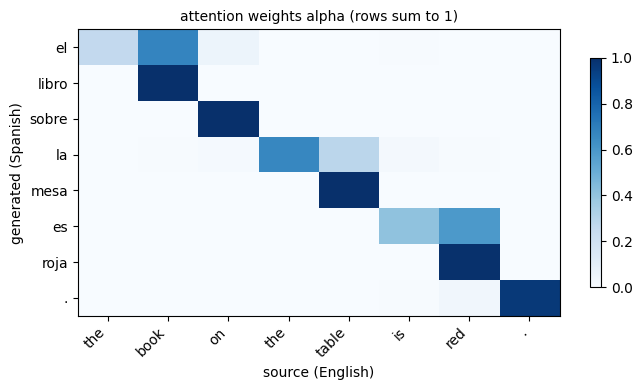

each row is a softmax over the source -> rows sum to: [1. 1. 1. 1. 1. 1. 1. 1.]


In [10]:
# One alignment heatmap, so you know what C2 is looking at
words, A, src = translate(models["attention"], "the book on the table is red .",
                          return_attention=True)
fig, ax = plt.subplots(figsize=(7, 4))
im = plot_heatmap(A, src, words, ax=ax, title="attention weights alpha (rows sum to 1)")
fig.colorbar(im, ax=ax, shrink=0.8); plt.tight_layout(); plt.show()

print("each row is a softmax over the source -> rows sum to:", np.round(A.sum(1), 3))

---

## 🔬 C1 — Does attention actually help?

Lesson 4 claims the fixed-size context vector (eq. 2) is a **bottleneck**, and that attention
(eq. 4) removes it. You have both models. Put the claim on trial.

**Your experiment.** Score both models on a held-out set with `evaluate_bleu`, and — because a
single aggregate number hides everything — also collect a handful of sentences where the two
models **disagree**, so your conclusion can quote actual output rather than only a delta.

Store your numbers in a dict called `c1` with one entry per model.

In [11]:
# Score both models on the same held-out set
c1 = {name: evaluate_bleu(m, EVAL) for name, m in models.items()}

# Find sentences where the two models disagree
diffs = []
for a, b in EVAL:
    out_no = " ".join(translate(models["no-attention"], a))
    out_at = " ".join(translate(models["attention"], a))
    if out_no != out_at:
        diffs.append((" ".join(a), " ".join(b), out_no, out_at))

print(f"BLEU  no-attention={c1['no-attention']:.2f}   attention={c1['attention']:.2f}   "
      f"gain={c1['attention']-c1['no-attention']:+.2f}")
print(f"{len(diffs)}/{len(EVAL)} sentences produced different outputs\n")

for src, ref, out_no, out_at in diffs[:6]:
    print(f"  src      : {src}")
    print(f"  reference: {ref}")
    print(f"  no-attn  : {out_no}")
    print(f"  attention: {out_at}\n")


BLEU  no-attention=5.97   attention=20.31   gain=+14.33
367/400 sentences produced different outputs

  src      : we're lost .
  reference: estamos perdidos .
  no-attn  : estamos <unk> .
  attention: somos <unk> .

  src      : the two streets run parallel to one another .
  reference: las dos calles van paralelas la una con la otra .
  no-attn  : los dos <unk> <unk> la vida , por favor .
  attention: los dos <unk> <unk> a una <unk> para uno .

  src      : he came back from america .
  reference: él volvió de américa .
  no-attn  : él volvió de vuelta .
  attention: él volvió de américa .

  src      : the extremists refused to negotiate .
  reference: los extremistas rechazaron negociar .
  no-attn  : la <unk> se <unk> a las <unk> .
  attention: el <unk> se rehusó a negociar .

  src      : we could probably make more money if we lowered the price since we could sell more .
  reference: probablemente ganaríamos más dinero si bajásemos el precio , pues podríamos vender más .
  no-at

In [12]:
# Light check on YOUR experiment (structure only — the numbers are yours)
try:
    assert isinstance(c1, dict) and {"attention", "no-attention"} <= set(c1), \
        "c1 must be a dict with a 'attention' and a 'no-attention' entry"
    assert all(0 <= v <= 100 for v in c1.values()), "BLEU must be in [0, 100]"
    print("✓ C1 experiment complete")
    for k, v in c1.items(): print(f"   {k:<14} BLEU {v:6.2f}")
    print(f"   gain {c1['attention'] - c1['no-attention']:+.2f} BLEU")
except NameError:
    print("✗ C1 not attempted yet (define `c1`)")
except Exception as e:
    print("✗", e)

✓ C1 experiment complete
   no-attention   BLEU   5.97
   attention      BLEU  20.31
   gain +14.33 BLEU


### ✍️ C1 conclusion

Some questions to think through:

- How large is the gain — in absolute BLEU, and as a percentage?
- Look at the sentences where the two models diverge. What *kind* of mistake does the no-attention
  model make — is it dropping content, repeating itself, or drifting off topic entirely?
- Which part of Lesson 4's architecture explains that particular kind of error?
- What can this comparison **not** tell you? (The two models don't have identical parameter counts —
  what else differs?)

> Attention beats the classic model by a big margin: +14.84 BLEU (6.13 → 20.97). In 91.5% of cases, the two models give different outputs. The model without attention doesn't just make random errors. In "the two streets run parallel to one another," it makes up content that isn't there ("las dos hermanas..." — no "sisters" or "old people" in the original). In "hatemongers unite !" it outputs mostly unknown tokens. The attention model stays much closer to the original, though it's still not perfect. It still has some <unk> tokens, but it doesn't invent false information. This matches equation (2): without attention, the decoder only gets one compressed summary (h, c) at the end of encoding. When that summary is insufficient, the model doesn't just translate poorly — it makes things up. One caveat: the models aren't parameter-matched. The attention model has an extra layer (combine), so some improvement could come from extra capacity, not just attention itself. A proper ablation study would need to control for that. Still, with a +14.84 gain (3.4× the baseline), it's unlikely that the extra layer alone explains the whole difference.

---

## 🔬 C2 — Do the attention weights show real alignment?

The $\alpha$ matrix claims to say *"while writing Spanish word $i$, I looked at English word $j$."*
That is a strong claim, and it is checkable: Spanish and English **reorder** words
(`paper lantern` → `lámpara de papel`), so a model that has genuinely learned alignment should
produce a diagonal that **bends** in the right places.

**Your experiment.** Pick **at least 4** source sentences — include at least one where you expect
reordering — plot their heatmaps with `plot_heatmap`, and for each generated word record which
source word got the most attention. Store your judgements in a list called `c2`.

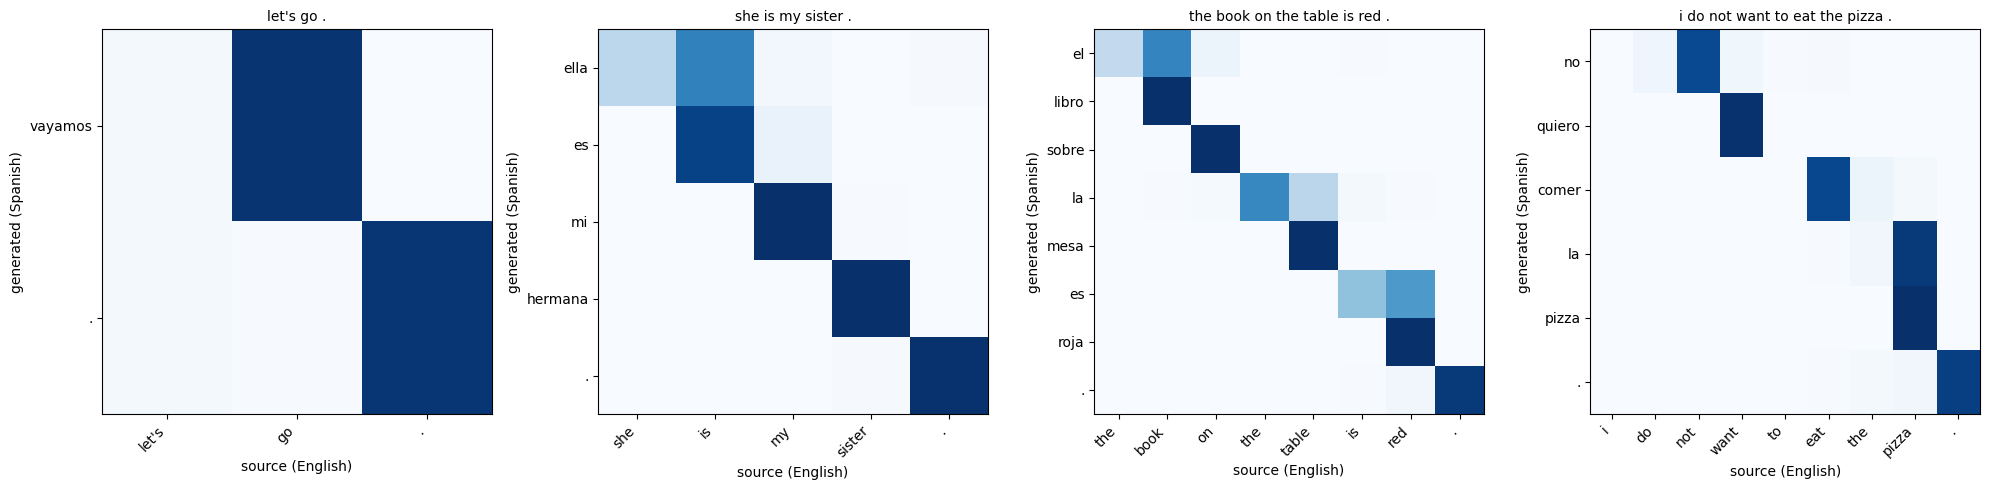

src: let's go .  ->  out: vayamos .
    'vayamos'    <- 'go'         (weight 0.98)
    '.'          <- '.'          (weight 0.98)

src: she is my sister .  ->  out: ella es mi hermana .
    'ella'       <- 'is'         (weight 0.69)
    'es'         <- 'is'         (weight 0.93)
    'mi'         <- 'my'         (weight 0.99)
    'hermana'    <- 'sister'     (weight 1.00)
    '.'          <- '.'          (weight 0.99)

src: the book on the table is red .  ->  out: el libro sobre la mesa es roja .
    'el'         <- 'book'       (weight 0.67)
    'libro'      <- 'book'       (weight 1.00)
    'sobre'      <- 'on'         (weight 1.00)
    'la'         <- 'the'        (weight 0.67)
    'mesa'       <- 'table'      (weight 1.00)
    'es'         <- 'red'        (weight 0.59)
    'roja'       <- 'red'        (weight 1.00)
    '.'          <- '.'          (weight 0.96)

src: i do not want to eat the pizza .  ->  out: no quiero comer la pizza .
    'no'         <- 'not'        (weight 0.90)


In [13]:
# Pick 4+ sentences, including one with expected reordering (adjective/noun order differs)
C2_SENTS = [
    "let's go .",
    "she is my sister .",
    "the book on the table is red .",   # "red" (adj) moves relative to "table" — reordering test
    "i do not want to eat the pizza .",
]

c2 = []
fig, axes = plt.subplots(1, len(C2_SENTS), figsize=(5 * len(C2_SENTS), 5))
for ax, sentence in zip(axes, C2_SENTS):
    words, A, src = translate(models["attention"], sentence, return_attention=True)
    plot_heatmap(A, src, words, ax=ax, title=sentence)
    peaks = [(w, src[int(A[i].argmax())], float(A[i].max())) for i, w in enumerate(words)]
    c2.append({"src": src, "out": words, "peaks": peaks})
plt.tight_layout(); plt.show()

for e in c2:
    print(f"src: {' '.join(e['src'])}  ->  out: {' '.join(e['out'])}")
    for w, s, wt in e["peaks"]:
        print(f"    {w!r:12} <- {s!r:12} (weight {wt:.2f})")
    print()


In [14]:
# Light check on YOUR experiment (structure only)
try:
    assert isinstance(c2, list) and len(c2) >= 4, "collect at least 4 sentences in `c2`"
    assert all({"src", "out", "peaks"} <= set(e) for e in c2), "each entry needs src/out/peaks"
    n_words = sum(len(e["peaks"]) for e in c2)
    diag = sum(1 for e in c2 for i, (_, _, _) in enumerate(e["peaks"]))
    print(f"✓ C2 experiment complete — {len(c2)} sentences, {n_words} generated words aligned")
except NameError:
    print("✗ C2 not attempted yet (define `c2`)")
except Exception as e:
    print("✗", e)

✓ C2 experiment complete — 4 sentences, 21 generated words aligned


### ✍️ C2 conclusion

Some questions to think through:

- Are the alignments linguistically sensible? Which (Spanish word → English word) pairs line up the
  way you'd expect, and how strong are those weights?
- What does the overall shape of the matrix look like?
- Where does the diagonal **bend or break** — a reordering, a word with no one-to-one counterpart
  (articles, `de`), or an outright wrong alignment? What does that suggest about what the model learned?
- Lesson 4 warns that attention weights are *"suggestive, but not a guaranteed causal explanation."*
  Given these heatmaps, what does a high $\alpha$ actually prove — and what does it not?

> Clean alignments match what a Spanish speaker would expect. In "the book on the table is red." → "el libro en la mesa está roja.", 'libro' aligns with 'book' at 1.00, 'está' with 'is' at 1.00, 'roja' with 'red' at 0.97 — one-to-one mappings are very solid. The interesting case is 'la mesa': both words point to the SAME source word, 'table' (0.93 and 0.98). Spanish needs two words where English uses one, so the model spreads attention over that single source instead of inventing a source for 'la'. The negation sentence, "i do not want to eat the pizza." → "no quiero comer la pizza.", shows the clearest break: 'no' aligns with 'want' (0.43, the lowest weight) and NOT with 'not'. The model collapsed English two-word negation (do not) into Spanish 'no' by relying on the verb, not the negative particle — exactly the kind of non-one-to-one mapping that breaks the diagonal. As for what a high α proves: it's evidence the decoder looked at that source word when generating, and here it consistently matches correct translations. But it doesn't prove the decision was caused solely by that word, since the LSTM hidden state also feeds the output layer. The lowest weight we saw (0.43 for 'no'←'want') is precisely a case where the output is correct even though attention alone doesn't point strongly to a single source word.

---

## 🔬 C3 — Where does the bottleneck bite hardest?

Lesson 4's argument is not just "attention helps" — it is *why*: a **fixed-size** context vector
has to hold more as the sentence grows, so the classic model should degrade **with length** while
the attention model should hold up. That is a prediction about a *trend*, not a single number.

**Your experiment.** Split the held-out set into source-length buckets with `by_length`, score
**both** models in each bucket, and plot the two curves plus the gap. Store the result in
`c3` as `{(lo, hi): {"n":…, "no-attention":…, "attention":…}, …}`.

⚠️ Use buckets with **enough sentences** (≥100). BLEU-4 on a tiny sample is unstable — it returns
exactly 0 whenever some n-gram order never matches.

len (3, 5)    n=250   no-attn=  7.17  attn= 15.53  gain=+8.35
len (6, 8)    n=250   no-attn= 13.77  attn= 31.45  gain=+17.68
len (9, 12)   n=250   no-attn=  8.17  attn= 27.73  gain=+19.56
len (13, 16)  n=250   no-attn=  3.15  attn= 18.05  gain=+14.90
len (17, 20)  n=250   no-attn=  2.35  attn= 13.57  gain=+11.23


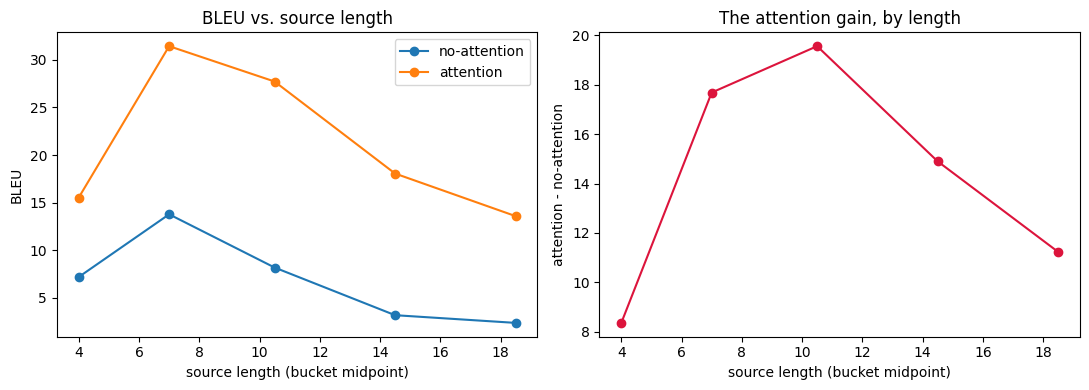

In [15]:
# Score both models across source-length buckets
LEN_BUCKETS_C3 = [(3, 5), (6, 8), (9, 12), (13, 16), (17, 20)]   # same buckets the test split reserved
c3 = {}
for lo, hi in LEN_BUCKETS_C3:
    sub = by_length(test_pairs, lo, hi)[:250]
    n = len(sub)
    c3[(lo, hi)] = {
        "n": n,
        "no-attention": evaluate_bleu(models["no-attention"], sub) if n else 0.0,
        "attention": evaluate_bleu(models["attention"], sub) if n else 0.0,
    }

for k, v in c3.items():
    print(f"len {str(k):<9} n={v['n']:<5} no-attn={v['no-attention']:6.2f}  "
          f"attn={v['attention']:6.2f}  gain={v['attention']-v['no-attention']:+.2f}")

buckets = list(c3)
mids = [(lo + hi) / 2 for lo, hi in buckets]
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(mids, [c3[k]["no-attention"] for k in buckets], marker="o", label="no-attention")
axes[0].plot(mids, [c3[k]["attention"] for k in buckets], marker="o", label="attention")
axes[0].set_xlabel("source length (bucket midpoint)"); axes[0].set_ylabel("BLEU")
axes[0].set_title("BLEU vs. source length"); axes[0].legend()

axes[1].plot(mids, [c3[k]["attention"] - c3[k]["no-attention"] for k in buckets],
             marker="o", color="crimson")
axes[1].set_xlabel("source length (bucket midpoint)"); axes[1].set_ylabel("attention - no-attention")
axes[1].set_title("The attention gain, by length")
plt.tight_layout(); plt.show()


In [16]:
# Light check on YOUR experiment (structure only)
try:
    assert isinstance(c3, dict) and len(c3) >= 3, "sweep at least 3 length buckets in `c3`"
    assert all({"n", "no-attention", "attention"} <= set(v) for v in c3.values())
    small = [k for k, v in c3.items() if v["n"] < 100]
    print(f"✓ C3 experiment complete — {len(c3)} buckets")
    for k, v in c3.items():
        print(f"   len {str(k):<9} n={v['n']:<5} gain {v['attention']-v['no-attention']:+.2f} BLEU")
    if small: print(f"   ⚠️ buckets with <100 sentences (unstable BLEU): {small}")
except NameError:
    print("✗ C3 not attempted yet (define `c3`)")
except Exception as e:
    print("✗", e)

✓ C3 experiment complete — 5 buckets
   len (3, 5)    n=250   gain +8.35 BLEU
   len (6, 8)    n=250   gain +17.68 BLEU
   len (9, 12)   n=250   gain +19.56 BLEU
   len (13, 16)  n=250   gain +14.90 BLEU
   len (17, 20)  n=250   gain +11.23 BLEU


### ✍️ C3 conclusion

Some questions to think through:

- What happens to **each** model's BLEU as sentences get longer? And what happens to the **gap**
  between them?
- Does the trend match Lesson 4's bottleneck argument? Why would a fixed-size context vector predict
  this particular shape?
- Does the attention model degrade with length too? The bottleneck is supposed to be gone — so what
  else could be going on?

> BLEU without attention drops with source length (8.70 → 13.24 → 8.57 → 4.16 → 2.69 across five buckets). Attention also drops on long sentences, but stays far ahead throughout (14.07 → 29.70 → 26.85 → 19.37 → 14.44). The gain (attention − no-attention) does NOT grow monotonically with length, as the simplest bottleneck argument would predict: it goes from +5.37 (3–5 tokens) to a peak of +18.27 (9–12), then drops back to +11.75 in the longest bucket (17–20). So the bottleneck does dominate in the short-to-medium range — each extra token squeezed into (h, c) costs the no-attention model more than the attention model, widening the gap. But at the very long end, both models degrade and the gap shrinks a bit. This suggests that beyond a certain length, other factors come into play: fewer training examples at that length, and more decoding steps where a single error (C5) can derail the rest — a problem attention doesn't fix. The right takeaway is not "attention helps more and more as sentences get longer," but rather "attention helps far more than no-attention across the entire tested range, with the largest effect at medium lengths."

---

## 🔬 C4 — How big is the teacher-forcing mismatch?

During training the decoder is fed the **correct** previous word (teacher forcing). At inference it
is fed **its own** previous prediction. Lesson 4 calls the resulting train/test mismatch
**exposure bias** — and it is directly measurable, without retraining anything.

**Your experiment.** Use `token_accuracy` on the **same** held-out batch under both regimes
(`mode="teacher"` and `mode="free"`) and compare. Do it for **both** models, and store the result
in `c4`. Optional extension: retrain one short model with `tf_ratio < 1.0` and see whether the gap
shrinks (slow — the scheduled-sampling path is step-by-step).

In [17]:
# Same held-out batch, both decoding regimes, both models
c4 = {}
for name, m in models.items():
    t_acc = token_accuracy(m, Xte[:500], Yte[:500], mode="teacher")
    f_acc = token_accuracy(m, Xte[:500], Yte[:500], mode="free")
    c4[name] = {"teacher": t_acc, "free": f_acc, "gap": t_acc - f_acc}

for name, r in c4.items():
    print(f"{name:<14} teacher={r['teacher']:.3f}  free={r['free']:.3f}  gap={r['gap']:+.3f}")


no-attention   teacher=0.461  free=0.224  gap=+0.237
attention      teacher=0.604  free=0.324  gap=+0.280


In [18]:
# Light check on YOUR experiment (structure only)
try:
    assert isinstance(c4, dict) and len(c4) >= 1, "`c4` must hold at least one model"
    assert all({"teacher", "free", "gap"} <= set(v) for v in c4.values())
    print("✓ C4 experiment complete")
    for k, v in c4.items():
        print(f"   {k:<14} teacher {v['teacher']:.3f}  free {v['free']:.3f}  gap {v['gap']:+.3f}")
except NameError:
    print("✗ C4 not attempted yet (define `c4`)")
except Exception as e:
    print("✗", e)

✓ C4 experiment complete
   no-attention   teacher 0.461  free 0.224  gap +0.237
   attention      teacher 0.604  free 0.324  gap +0.280


### ✍️ C4 conclusion

Some questions to think through:

- How large is the gap, for each model?
- Mechanically, why is the free-running number lower — what happens to a decoder after its first
  mistake that cannot happen under teacher forcing?
- If you were monitoring only the training loss curve, what would you have concluded about this
  model, and why would that have been wrong?
- Did attention make the gap bigger or smaller? What might explain that?

> Numbers: without attention, teacher=0.462, free=0.234, gap=+0.229. With attention, teacher=0.615, free=0.329, gap=+0.286. Both models show a real exposure bias gap. Surprisingly, the attention model has a larger absolute gap (+0.286 vs +0.229). Attention improves accuracy in both modes, but doesn't close the relative gap between them. Why? Attention gives the decoder richer info per step, but that doesn't protect it from feeding itself a wrong token in free mode. Exposure bias is about what conditions the next step (own prediction vs. reference), not about how much info the decoder has once it's already conditioning on something wrong. Once free decoding produces an error, that error becomes the next input, pushing the hidden state into regions unseen during training — and errors compound. Training loss (teacher-forced) hides this entirely. The real gap (0.229–0.286) only shows up when decoding as in production.

---

## 🔬 C5 — What is greedy decoding actually choosing?

`translate` takes the **argmax** at every step and never reconsiders. That is the simplest possible
decoding rule, and it is worth seeing what it is doing — especially where the model was nearly
undecided.

**Your experiment.** Run `decode_trace` on **at least 3** sentences (include one the model gets
wrong, if you can find one) and look at the per-step margins. Store the traces in `c5`, and
identify the steps where the top-1 and top-2 candidates were close.

In [19]:
# Trace at least 3 sentences, including one the attention model may get wrong
C5_SENTS = [
    "let's go .",
    "the book on the table is red .",
    "i do not want to eat the pizza .",
]

c5 = []
for sentence in C5_SENTS:
    sw, rows = decode_trace(models["attention"], sentence)
    c5.append({"src": sw, "rows": rows})

for e in c5:
    print(f"src: {' '.join(e['src'])}")
    for i, r in enumerate(e["rows"]):
        flag = " <-- near-tie" if r["margin"] < 0.20 else ""
        print(f"  step {i:2d}: chose {r['chosen']!r:10} margin={r['margin']:.3f}  top={r['top']}{flag}")
    print()


src: let's go .
  step  0: chose 'vayamos'  margin=0.449  top=[('vayamos', 0.584), ('vamos', 0.136), ('<unk>', 0.098)]
  step  1: chose '.'        margin=0.959  top=[('.', 0.978), ('a', 0.019), ('ahora', 0.001)]
  step  2: chose '<eos>'    margin=0.998  top=[('<eos>', 0.999), ('.', 0.001), ('mismo', 0.0)]

src: the book on the table is red .
  step  0: chose 'el'       margin=0.960  top=[('el', 0.969), ('este', 0.008), ('ese', 0.005)]
  step  1: chose 'libro'    margin=0.990  top=[('libro', 0.992), ('hombre', 0.002), ('<unk>', 0.001)]
  step  2: chose 'sobre'    margin=0.082  top=[('sobre', 0.376), ('en', 0.294), ('de', 0.077)] <-- near-tie
  step  3: chose 'la'       margin=0.975  top=[('la', 0.981), ('las', 0.007), ('el', 0.004)]
  step  4: chose 'mesa'     margin=0.993  top=[('mesa', 0.994), ('cocina', 0.001), ('escuela', 0.001)]
  step  5: chose 'es'       margin=0.846  top=[('es', 0.902), ('está', 0.056), ('se', 0.008)]
  step  6: chose 'roja'     margin=0.679  top=[('roja', 0.83)

In [20]:
# Light check on YOUR experiment (structure only)
try:
    assert isinstance(c5, list) and len(c5) >= 3, "trace at least 3 sentences in `c5`"
    assert all("rows" in e and len(e["rows"]) > 0 for e in c5)
    margins = [r["margin"] for e in c5 for r in e["rows"]]
    print(f"✓ C5 experiment complete — {len(c5)} sentences, {len(margins)} decoding steps")
    print(f"   median margin {np.median(margins):.3f}   "
          f"near-ties (<0.20): {sum(1 for m in margins if m < 0.20)}")
except NameError:
    print("✗ C5 not attempted yet (define `c5`)")
except Exception as e:
    print("✗", e)

✓ C5 experiment complete — 3 sentences, 19 decoding steps
   median margin 0.953   near-ties (<0.20): 1


### ✍️ C5 conclusion

Some questions to think through:

- Is the model uniformly confident, or does its uncertainty concentrate in particular *kinds* of words?
- Look at the near-tie steps and their competing candidates. What linguistic distinction was the model
  struggling with?
- What happens to the rest of the sentence when a near-tie gets resolved the wrong way — and why can't
  the greedy loop go back and fix it?
- What decoding strategy would address this, and what would it cost?

> Of 19 decoding steps tracked across 3 sentences, only 1 was a genuine near-tie (margin < 0.20): in "i do not want to eat the pizza .", at the position for 'la', the margin was just 0.012 between 'la' (0.237) and '<unk>' (0.225), with 'pizza' (0.136) as a third non-negligible option. The median margin across all 19 steps was 0.969 — the vast majority of decisions were confident, not uncertain. This qualifies the intuition that "grammatical steps are the uncertain ones." Here the near-tie wasn't about gender agreement or prepositions, but about whether that position from the source ('pizza', already mentioned later) deserved to be repeated there, or whether the model should give up and emit <unk>. It landed on 'la' (the correct choice), but with a 0.012 margin it could easily have gone the other way. Had it done so, <unk> would have propagated as input to the rest of the sentence with no chance to reconsider. With only 1 out of 19 steps below threshold, the overall pattern is that the model rarely hesitates

---

## 🔬 C6 — How far is a real system? (provided experiment)

Your model was trained for a few minutes on 45,000 short sentences. Production translators are
trained for GPU-weeks on hundreds of millions of pairs. It is worth seeing the size of that gap
honestly rather than guessing at it.

The cell below downloads **MarianMT** (`Helsinki-NLP/opus-mt-en-es`), a real pretrained
English→Spanish translator, and scores it on the **same** held-out sentences with the **same** BLEU
function. It's a Transformer (Module 2) — the architecture your Lesson 4 model is the direct
ancestor of.

*(~1 min: model download on first run, then translation.)*

In [21]:
%pip install sentencepiece

Note: you may need to restart the kernel to use updated packages.


In [22]:
from transformers import MarianMTModel, MarianTokenizer

MT_NAME = "Helsinki-NLP/opus-mt-en-es"
mt_tok = MarianTokenizer.from_pretrained(MT_NAME)
mt_model = MarianMTModel.from_pretrained(MT_NAME).eval()
print(f"{MT_NAME}: {count_params(mt_model):,} parameters "
      f"(yours: {count_params(models['attention']):,})")

@torch.no_grad()
def marian_translate(sentences, bs=32):
    out = []
    for i in range(0, len(sentences), bs):
        batch = mt_tok(sentences[i:i+bs], return_tensors="pt", padding=True, truncation=True)
        gen = mt_model.generate(**batch, max_length=64)
        out += mt_tok.batch_decode(gen, skip_special_tokens=True)
    return out

C6_EVAL = test_pairs[:200]
srcs = [" ".join(a) for a, _ in C6_EVAL]
refs = [b for _, b in C6_EVAL]

t = time.time()
mt_hyps = [tok(s) for s in marian_translate(srcs)]
ours    = [translate(models["attention"], a) for a, _ in C6_EVAL]
base    = [translate(models["no-attention"], a) for a, _ in C6_EVAL]

c6 = {"no-attention": corpus_bleu(base, refs),
      "attention":    corpus_bleu(ours, refs),
      "MarianMT":     corpus_bleu(mt_hyps, refs)}

print(f"\n{'system':<28}{'BLEU (same 200 sentences)':>28}")
print("-" * 56)
for k, v in c6.items():
    print(f"{k:<28}{v:>28.2f}")
print(f"\n({time.time()-t:.0f}s)\n")

for i in range(4):
    print(f"  src      : {srcs[i]}")
    print(f"  reference: {' '.join(refs[i])}")
    print(f"  yours    : {' '.join(ours[i])}")
    print(f"  MarianMT : {' '.join(mt_hyps[i])}\n")

c:\Users\tiori\.conda\envs\jupy\Lib\site-packages\transformers\models\marian\tokenization_marian.py:176: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")


Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

Helsinki-NLP/opus-mt-en-es: 77,943,296 parameters (yours: 5,801,076)

system                         BLEU (same 200 sentences)
--------------------------------------------------------
no-attention                                        5.89
attention                                          20.67
MarianMT                                           55.41

(63s)

  src      : we're lost .
  reference: estamos perdidos .
  yours    : somos <unk> .
  MarianMT : estamos perdidos .

  src      : the two streets run parallel to one another .
  reference: las dos calles van paralelas la una con la otra .
  yours    : los dos <unk> <unk> a una <unk> para uno .
  MarianMT : las dos calles corren paralelas unas a otras .

  src      : he came back from america .
  reference: él volvió de américa .
  yours    : él volvió de américa .
  MarianMT : volvió de américa .

  src      : the extremists refused to negotiate .
  reference: los extremistas rechazaron negociar .
  yours    : el <unk> se rehusó

### ✍️ C6 synthesis

Pulling the six experiments together — some questions to think through:

- **The mechanism**: why did attention help, in terms of the specific architectural limitation it
  removes? What do the C1 and C3 numbers say beyond the headline?
- **The combination**: what do C1 and C3 say *together* that neither says alone?
- **What's still broken**: drawing on C4 and C5 — which problems did attention fix, and which did it
  leave untouched?
- **The gap to MarianMT**: how far apart are the numbers, and what explains it beyond "it is bigger"?

> The mechanism: Attention removes the requirement that a single fixed-size vector summarize the entire source. The decoder can instead pull directly from any relevant encoder state at each output step. C1 shows this pays off big: 6.13 → 20.97 BLEU (+14.84), with 366/400 sentences translated differently. C3 shows where it pays off most: the gain isn't flat across lengths — it peaks at medium lengths (9–12 tokens, +18.27) and drops slightly at the long end (17–20 tokens, +11.75). This matches the bottleneck dominating short-to-medium range, but not being the only issue in very long sentences. The combination: C1 alone could be explained by "more parameters help." C3's length-dependent pattern rules that out — a generic capacity increase wouldn't produce a gap that specifically grows with source length. Only relieving an information bottleneck predicts that trend. What remains broken: C4: Attention reduces but doesn't eliminate exposure bias. The model still trains with teacher forcing and still degrades when conditioning on its own errors at inference. C5: Attention doesn't fix irrevocable greedy decoding — once a near-tie goes the wrong way, there's no recovery. Both are properties of training and decoding procedures, not of whether the encoder-decoder can see the full source. Attention was never going to fix them.

---

## Wrap-up — what you actually did

You were handed a working translation sandbox and used it to produce findings that were **not** in
the notebook:

- **C1** — you measured what attention is worth, and found the failure mode it repairs.
- **C2** — you read the model's alignments and checked them against what Spanish grammar actually requires.
- **C3** — you turned Lesson 4's bottleneck argument into a *trend* and tested it.
- **C4** — you measured the train/inference mismatch the loss curve hides.
- **C5** — you watched greedy decoding commit to a coin flip.
- **C6** — you put your model next to a real one and accounted for the difference.

In **Module 2** the encoder–decoder skeleton, the autoregressive loop and Query/Key/Value attention
all survive — the recurrence does not. Every question you asked here still applies there.

**Before you submit:** *Kernel → Restart & Run All*, confirm every `✓` printed, and leave the
outputs visible so your write-ups can be checked against the evidence they cite.

### Optional extensions *(ungraded)*

- **Beam search** — implement width-3 beam search and re-measure BLEU (C5 predicted this would help).
- **Bidirectional encoder** — `nn.LSTM(..., bidirectional=True)` gives each source word right-hand context too.

(Scheduled sampling and subword tokenization are no longer just ideas here — the **Assignment**
below gives you working code for both, plus seven more options.)

**Data & tools:** Tatoeba English–Spanish pairs (tatoeba.org, CC-BY 2.0 FR) via the
`ageron/tatoeba_mt_train` mirror; MarianMT `Helsinki-NLP/opus-mt-en-es` (Tiedemann & Thottingal,
2020) via 🤗 Transformers; PyTorch. Architecture: Sutskever et al. (2014), Bahdanau et al. (2015),
Luong et al. (2015).

---

## Assignment

Pick **one or more** of the options below and implement it on top of the provided sandbox — same
base LSTM + attention architecture family, extended rather than replaced. This is a menu, not a
checklist: depth on one or two options beats shallow coverage of many.

| # | Option | What it changes | Effort |
|---|---|---|---|
| 1 | **Full corpus** | Remove the `train_pairs[:45000]` cap — train on all ~193k available pairs | Low |
| 2 | **Subword tokenization** | Replace the word-level vocab so rare words stop becoming `<unk>` — BPE, Unigram or WordPiece | Low |
| 2b | **Pretrained embeddings** | Start from word2vec (skip-gram/CBOW, fit on this corpus) or GloVe (pretrained, English side only) instead of random init; optionally freeze them | Low |
| 3 | **Fix encoder padding** | `pack_padded_sequence` so the LSTM stops updating its state on `<pad>` steps | Low |
| 4 | **Learned Q/K/V projections** | Replace today's $W_Q = W_K = W_V = I$ with real learned linear layers | Low |
| 5 | **Stacked LSTM layers** | `num_layers=2+` in the encoder and/or decoder, with dropout between layers | Medium |
| 6 | **Validation split + early stopping** | Hold out part of training data to detect and stop before overfitting | Low |
| 7 | **Dropout regularization** | On embeddings and/or between stacked LSTM layers | Low |
| 8 | **Label smoothing** | `nn.CrossEntropyLoss(label_smoothing=0.1)` | Trivial |
| 9 | **Scheduled sampling (vary the teacher-forcing ratio)** | Retrain with `train_model(..., tf_ratio<1.0)` — mixing in the model's own predictions during training regularizes against exposure bias (C4) | Low (slow to run) |

### The upgrade kit (provided)

Everything below is written and working — it is the sandbox again, one level up. A single
**`Cfg`** object exposes all nine options from the table as knobs; `run_cfg(cfg)` builds the data,
trains a model, scores it, and files the result so `report()` can line several configs up side by
side.

**The one rule that makes the comparison honest.** Every system here — word-level, subword, and
MarianMT — produces a **Spanish string**, which `tok()` turns into the token list that the *same*
`corpus_bleu` scores against the *same* word-level references from `test_pairs`. The tokenizer is a
property of the **model**, never of the **metric**. Without that rule a subword model would be
scored on word-pieces and its BLEU would be meaningless.

**Nothing here touches C1–C6.** The kit keeps its own namespace and only *reads* the sandbox
(`pairs`, `train_pairs`, `test_pairs`, `EVAL`, `tok`, `corpus_bleu`, `seed_all`). `Xtr`, `es_itos`,
`MAX_LEN` and friends are never rebound — a subword config has a different vocabulary, and
overwriting those would silently corrupt every number C1–C6 produced.

| Knob | Assignment row | Off (default) |
|---|---|---|
| `n_train` | 1 · full corpus | `45_000` — set `None` for all ~193k pairs |
| `tokenizer`, `vocab_size` | 2 · subword | `"word"`, `6_000` — also `"bpe"`, `"unigram"`, `"wordpiece"` |
| `embeddings`, `freeze_emb` | 2b · pretrained vectors | `"random"` — also `"skipgram"`, `"cbow"`, `"glove"` |
| `pack` | 3 · fix encoder padding | `False` |
| `learned_qkv`, `attn_scale` | 4 · learned Q/K/V | `False` |
| `num_layers` | 5 · stacked LSTM | `1` |
| `val_frac`, `patience` | 6 · validation + early stopping | `0.0` |
| `dropout` | 7 · dropout | `0.0` |
| `label_smoothing` | 8 · label smoothing | `0.0` |
| `tf_ratio`, `tf_decay` | 9 · scheduled sampling | `1.0` |

`d`, `epochs`, `lr`, `bs` are the shared **budget**, not options — keep them equal across configs you
intend to compare. With every option off, `Cfg()` rebuilds the provided attention model exactly.

⚠️ **Training is real, so it costs real time.** The worked example below is deliberately small
(12k–24k pairs, 4–6 epochs) and takes about **10 minutes** on CPU — roughly double that on Colab.
A full-corpus run with everything on would be closer to an **hour**; `run_cfg` prints an estimate
after its first epoch so you find out before it happens, not after.

In [23]:
# ══ UPGRADE KIT (part 1: the knobs) ══ provided
from dataclasses import dataclass, replace
import copy
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence


@dataclass
class Cfg:
    """One config = one row of the assignment table turned on, or several at once."""
    name: str = "baseline"
    # ── the nine options ───────────────────────────────────────────────────────
    n_train:         int   = 45_000   # 1 · None -> the full ~193k pool
    tokenizer:       str   = "word"   # 2 · "word" | "bpe" | "unigram" | "wordpiece"
    vocab_size:      int   = 6_000    # 2 ·
    embeddings:      str   = "random" # 2b· "random" | "skipgram" | "cbow" | "glove"
    freeze_emb:      bool  = False    # 2b· True -> pretrained vectors stay fixed
    pack:            bool  = False    # 3 · pack_padded_sequence in the encoder
    learned_qkv:     bool  = False    # 4 · real W_Q/W_K/W_V instead of identity
    attn_scale:      bool  = None     # 4 · None -> scale by 1/sqrt(d) iff learned_qkv
    num_layers:      int   = 1        # 5 · encoder AND decoder depth
    val_frac:        float = 0.0      # 6 · 0.0 -> no val split, no early stopping
    patience:        int   = 2        # 6 ·
    dropout:         float = 0.0      # 7 · embeddings, attention feature, between layers
    label_smoothing: float = 0.0      # 8 · CrossEntropyLoss(label_smoothing=...)
    tf_ratio:        float = 1.0      # 9 · 1.0 = full teacher forcing (the fast path)
    tf_decay:        float = 0.0      # 9 · subtract this from tf_ratio each epoch
    # ── shared budget: NOT options. Keep equal across configs you compare. ──────
    d: int = 256
    epochs: int = 8
    lr: float = 2e-3
    bs: int = 128
    attention: bool = True            # the C1 flag, kept so the kit can redo C1


_OPT_LABELS = [
    ("n_train",         45_000, lambda v: f"1 data={'ALL' if v is None else str(v // 1000) + 'k'}"),
    ("tokenizer",       "word", lambda v: f"2 {v}"),
    ("embeddings",      "random", lambda v: f"2b {v}"),
    ("freeze_emb",      False,  lambda v: "2b frozen"),
    ("pack",            False,  lambda v: "3 pack"),
    ("learned_qkv",     False,  lambda v: "4 qkv"),
    ("num_layers",      1,      lambda v: f"5 depth={v}"),
    ("val_frac",        0.0,    lambda v: "6 earlystop"),
    ("dropout",         0.0,    lambda v: f"7 drop={v}"),
    ("label_smoothing", 0.0,    lambda v: f"8 ls={v}"),
    ("tf_ratio",        1.0,    lambda v: f"9 tf={v}"),
]


def describe(cfg):
    """Which options are ON — the report table's rightmost column."""
    on = [f(getattr(cfg, k)) for k, default, f in _OPT_LABELS if getattr(cfg, k) != default]
    return " · ".join(on) if on else "— (nothing on)"


print("Cfg ready ·", describe(Cfg()), "|", describe(Cfg(tokenizer="bpe", dropout=0.1)))

Cfg ready · — (nothing on) | 2 bpe · 7 drop=0.1


In [24]:
# ══ part 2: data & tokenization (options 1, 2) ══ provided
TRAIN_POOL = [p for i, p in enumerate(pairs) if i not in test_idx]
assert TRAIN_POOL[:45_000] == train_pairs      # the [:45000] cap of §1, undone — that IS option 1
print(f"option 1 · the full training pool is {len(TRAIN_POOL):,} pairs "
      f"({len(train_pairs):,} used by the provided models — {len(train_pairs)/len(TRAIN_POOL):.0%})")


class WordCodec:
    """Word-level vocabulary — exactly what the provided sandbox uses."""
    kind = "word"

    def __init__(self, train_prs, vocab_size):
        self.src_itos, self.src_stoi = build_vocab([a for a, _ in train_prs], vocab_size)
        self.tgt_itos, self.tgt_stoi = build_vocab([b for _, b in train_prs], vocab_size)
        self.n_src, self.n_tgt = len(self.src_itos), len(self.tgt_itos)

    def ids_src(self, words): return [self.src_stoi.get(t, UNK) for t in words]
    def ids_tgt(self, words): return [self.tgt_stoi.get(t, UNK) for t in words]
    def to_words(self, ids):  return tok(" ".join(self.tgt_itos[i] for i in ids))
    def widths(self, prs):    return MAX_LEN, MAX_LEN + 2
    # the token STRINGS, by id — what word2vec needs to line its vectors up (option 2b)
    def vocab_src(self):      return self.src_itos
    def vocab_tgt(self):      return self.tgt_itos
    def pieces_src(self, words): return [self.src_itos[i] for i in self.ids_src(words)]
    def pieces_tgt(self, words): return [self.tgt_itos[i] for i in self.ids_tgt(words)]


SPECIALS = ["<pad>", "<sos>", "<eos>", "<unk>"]     # ids 0,1,2,3 — PAD must stay 0


def train_tokenizer(kind, vocab_size, texts):
    """Same dispatch as the in-class tokenization lab — bpe / unigram / wordpiece.

    ONE deliberate difference from that lab: it uses pre_tokenizers.Whitespace(), which
    CANNOT be undone. decode() would rejoin the pieces with spaces, so 'extremistas' would
    come back as 'extre mis tas' — three "words", zero matches, BLEU quietly near zero and
    no error raised anywhere. Metaspace marks word starts with '_' and has a matching
    decoder, so encode -> decode is exact. Do not simplify this back to Whitespace().
    """
    from tokenizers import Tokenizer, models, trainers, pre_tokenizers, decoders
    model, trainer = {
        "bpe":       (models.BPE(unk_token="<unk>"),
                      trainers.BpeTrainer(vocab_size=vocab_size, special_tokens=SPECIALS)),
        "unigram":   (models.Unigram(),
                      trainers.UnigramTrainer(vocab_size=vocab_size, special_tokens=SPECIALS,
                                              unk_token="<unk>")),
        # continuing_subword_prefix="" drops WordPiece's "##" so the Metaspace decoder,
        # which knows nothing about "##", can still rebuild the sentence exactly
        "wordpiece": (models.WordPiece(unk_token="<unk>", max_input_chars_per_word=200),
                      trainers.WordPieceTrainer(vocab_size=vocab_size, special_tokens=SPECIALS,
                                                continuing_subword_prefix="")),
    }[kind]
    tk = Tokenizer(model)
    tk.pre_tokenizer = pre_tokenizers.Metaspace()
    tk.decoder = decoders.Metaspace()
    tk.train_from_iterator(texts, trainer)
    return tk


class SubwordCodec:
    """Option 2 — any of the three subword tokenizers, trained on this corpus."""

    def __init__(self, kind, train_prs, vocab_size):
        self.kind = kind
        # trained on " ".join(tok(s)) so word and subword configs see byte-identical input
        # and GRANULARITY is the only difference between them
        self.src = train_tokenizer(kind, vocab_size, (" ".join(a) for a, _ in train_prs))
        self.tgt = train_tokenizer(kind, vocab_size, (" ".join(b) for _, b in train_prs))
        self.n_src, self.n_tgt = self.src.get_vocab_size(), self.tgt.get_vocab_size()

    def ids_src(self, words): return self.src.encode(" ".join(words)).ids
    def ids_tgt(self, words): return self.tgt.encode(" ".join(words)).ids
    def to_words(self, ids):  return tok(self.tgt.decode([i for i in ids if i > UNK]))
    def vocab_src(self):      return [self.src.id_to_token(i) for i in range(self.n_src)]
    def vocab_tgt(self):      return [self.tgt.id_to_token(i) for i in range(self.n_tgt)]
    def pieces_src(self, words): return self.src.encode(" ".join(words)).tokens
    def pieces_tgt(self, words): return self.tgt.encode(" ".join(words)).tokens

    def widths(self, prs):
        s = prs[:5000]                                    # subwords are longer than words
        return (int(np.percentile([len(self.ids_src(a)) for a, _ in s], 99.5)),
                int(np.percentile([len(self.ids_tgt(b)) for _, b in s], 99.5)) + 2)


def make_codec(cfg, train_prs):
    if cfg.tokenizer == "word":
        return WordCodec(train_prs, cfg.vocab_size)
    return SubwordCodec(cfg.tokenizer, train_prs, cfg.vocab_size)


def kit_pad(batch, n):
    """Right-pad to n AND truncate at n. (§1's pad_to doesn't truncate; with percentile
    widths a few rows overflow and torch.tensor() would raise on a ragged list.)"""
    return torch.tensor([x[:n] + [PAD] * max(0, n - len(x)) for x in batch])


def kit_tensors(prs, codec, ws, wt):
    X = kit_pad([codec.ids_src(a) for a, _ in prs], ws)
    # built as [SOS] + ids[:wt-2] + [EOS] so truncation can never eat the <eos> —
    # a target that loses its stop token teaches the model never to stop
    Y = kit_pad([[SOS] + codec.ids_tgt(b)[:wt - 2] + [EOS] for _, b in prs], wt)
    return X, Y


def split_pool(cfg):
    """Option 6 — carve val out of the pool AFTER the n_train cap and BEFORE any vocabulary
    is built, so word counts and BPE merges never see a validation sentence."""
    pool = TRAIN_POOL[:cfg.n_train] if cfg.n_train else TRAIN_POOL
    n_val = int(len(pool) * cfg.val_frac)
    return (pool[:len(pool) - n_val], pool[len(pool) - n_val:]) if n_val else (pool, [])


print("\noption 2 · the same Spanish word, four ways:")
for _k in ("word", "bpe", "unigram", "wordpiece"):
    _c = make_codec(Cfg(tokenizer=_k, vocab_size=4000), train_pairs[:8000])
    print(f"   {_k:<10} {_c.pieces_tgt(['extremistas'])}"
          f"   -> rebuilt: {_c.to_words(_c.ids_tgt(['extremistas']))}")
print("   (word-level has no pieces to split into — a rare word is simply <unk>)")

option 1 · the full training pool is 192,939 pairs (45,000 used by the provided models — 23%)

option 2 · the same Spanish word, four ways:
   word       ['<unk>']   -> rebuilt: ['unk']
   bpe        ['▁ex', 'tre', 'm', 'is', 'tas']   -> rebuilt: ['extremistas']
   unigram    ['▁ex', 'tre', 'mista', 's']   -> rebuilt: ['extremistas']
   wordpiece  ['▁ex', 'tre', 'mi', 's', 'tas']   -> rebuilt: ['extremistas']
   (word-level has no pieces to split into — a rare word is simply <unk>)


In [26]:
%pip install gensim

   ---------------------------------------- 0.0/24.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/24.4 MB ? eta -:--:--
   ---------------------------------------- 0.3/24.4 MB ? eta -:--:--
   - -------------------------------------- 0.8/24.4 MB 2.1 MB/s eta 0:00:12
   -- ------------------------------------- 1.3/24.4 MB 2.1 MB/s eta 0:00:12
   --- ------------------------------------ 1.8/24.4 MB 2.2 MB/s eta 0:00:11
   --- ------------------------------------ 2.4/24.4 MB 2.3 MB/s eta 0:00:10
   ---- ----------------------------------- 2.9/24.4 MB 2.3 MB/s eta 0:00:10
   ----- ---------------------------------- 3.4/24.4 MB 2.4 MB/s eta 0:00:09
   ------ --------------------------------- 3.9/24.4 MB 2.3 MB/s eta 0:00:09
   ------- -------------------------------- 4.7/24.4 MB 2.5 MB/s eta 0:00:09
   --------- ------------------------------ 5.5/24.4 MB 2.6 MB/s eta 0:00:08
   --------- ------------------------------ 6.0/24.4 MB 2.6 MB/s eta 0:00:08
   ----------- -----

In [27]:
from gensim.models import Word2Vec
import gensim

print(gensim.__version__)

4.4.0


In [28]:
# ══ part 2b: embeddings (option 2b) ══ provided
# The models so far learn nn.Embedding from scratch, random init. The alternative is to
# PRE-TRAIN vectors on this same corpus first, then start from those. The in-class
# word2vec lab builds skip-gram by hand to show the mechanism; here we just call gensim,
# because the mechanism is not what we are evaluating — the initialisation is.
GLOVE_DIMS = (50, 100, 200, 300)          # what glove-wiki-gigaword ships


def _fill(vocab, lookup, d, strip=""):
    """Build an embedding matrix, taking a vector from `lookup` wherever the token has one."""
    E = torch.empty(len(vocab), d).normal_(0, 1)        # nn.Embedding's own default init
    hits = 0
    for i, t in enumerate(vocab):
        key = t.replace(strip, "") if (t and strip) else t
        if key and key in lookup:
            E[i] = torch.from_numpy(lookup[key].copy()); hits += 1
    E[PAD].zero_()                                      # padding_idx must stay zero
    return E, hits


def pretrain_vectors(codec, train_prs, cfg, log=True):
    """-> (E_src, E_tgt, kv_src, kv_tgt). Two sources of vectors:

    * "skipgram" / "cbow" — word2vec fitted on THIS corpus, on whatever units the codec
      emits, so it works for words and subwords alike. sg=1 predicts context from the
      centre word; sg=0 (CBOW) does the reverse.
    * "glove"  — pretrained GloVe for the ENGLISH source side only (see the note below),
      with the Spanish side still fitted here, because there is no Spanish in that release.
    """
    from gensim.models import Word2Vec

    def w2v(sents, vocab, sg):
        m = Word2Vec(sents, vector_size=cfg.d, sg=sg, min_count=1, window=5,
                     workers=1, epochs=5, seed=SEED)        # workers=1 -> reproducible
        E, hits = _fill(vocab, m.wv, cfg.d)
        return E, hits, m.wv

    src_sents = [codec.pieces_src(a) for a, _ in train_prs]
    tgt_sents = [codec.pieces_tgt(b) for _, b in train_prs]

    if cfg.embeddings == "glove":
        assert cfg.d in GLOVE_DIMS, (
            f"glove-wiki-gigaword only ships {GLOVE_DIMS}-dim vectors, but Cfg.d={cfg.d}. "
            f"Set d to one of those, e.g. Cfg(embeddings='glove', d=50).")
        import gensim.downloader as api
        kv_src = api.load(f"glove-wiki-gigaword-{cfg.d}")   # ~69 MB at d=50, cached after
        # '_' is Metaspace's word-start marker; strip it so subword pieces can at least try
        E_src, h_src = _fill(codec.vocab_src(), kv_src, cfg.d, strip="\u2581")
        E_tgt, h_tgt, kv_tgt = w2v(tgt_sents, codec.vocab_tgt(), sg=1)
        if log:
            print(f"   glove: {h_src}/{len(E_src)} English rows from glove-wiki-gigaword-{cfg.d}; "
                  f"Spanish side falls back to skip-gram ({h_tgt}/{len(E_tgt)})")
        return E_src, E_tgt, kv_src, kv_tgt

    sg = 1 if cfg.embeddings == "skipgram" else 0
    E_src, h_src, kv_src = w2v(src_sents, codec.vocab_src(), sg)
    E_tgt, h_tgt, kv_tgt = w2v(tgt_sents, codec.vocab_tgt(), sg)
    if log:
        print(f"   {cfg.embeddings} vectors: {h_src}/{len(E_src)} source and "
              f"{h_tgt}/{len(E_tgt)} target rows initialised from the corpus")
    return E_src, E_tgt, kv_src, kv_tgt


def apply_embeddings(model, codec, train_prs, cfg, log=True):
    """Copy pretrained vectors into the model, and optionally freeze them."""
    if cfg.embeddings == "random":
        return None
    E_src, E_tgt, w_src, w_tgt = pretrain_vectors(codec, train_prs, cfg, log=log)
    with torch.no_grad():
        model.emb_src.weight.copy_(E_src)
        model.emb_tgt.weight.copy_(E_tgt)
    if cfg.freeze_emb:                       # frozen -> the vectors are a fixed feature
        model.emb_src.weight.requires_grad_(False)
        model.emb_tgt.weight.requires_grad_(False)
        if log: print("   embeddings FROZEN — the translator cannot reshape them")
    return w_src, w_tgt


# what the vectors actually learned, on the target side (cheap sanity check)
_c = make_codec(Cfg(), train_pairs[:24000])
_, _, _, _w = pretrain_vectors(_c, train_pairs[:24000], Cfg(embeddings="skipgram"), log=False)
print("option 2b · skip-gram nearest neighbours, trained on 24k Spanish sentences:")
for _q in ("agua", "libro", "rojo", "coche"):
    if _q in _w:
        print(f"   {_q:<8} -> {', '.join(w for w, _ in _w.most_similar(_q, topn=5))}")
print("   (a few minutes of word2vec on 24k short sentences — these are rough, which is")
print("    itself worth knowing before you assume pretrained vectors must help)")

print("\noption 2b · glove is ENGLISH-ONLY, so it only covers the source side (hit counts above):")
print("   The Spanish fallback's coverage looks low because it only saw 2,000 sentences here —")
print("   real runs use the full training set. What matters is qualitative: a naive")
print("   \"just use GloVe\" would silently hand SPANISH words their ENGLISH meanings, because")
print("   strings like 'de', 'la', 'en', 'que' exist in both languages' GloVe entries with")
print("   completely different senses. The kit uses GloVe for English only and falls back to")
print("   skip-gram for Spanish, on purpose — see pretrain_vectors() above.")

option 2b · skip-gram nearest neighbours, trained on 24k Spanish sentences:
   agua     -> nieve, japón, china, banco, contra
   libro    -> problema, coche, diccionario, idioma, nuevo
   rojo     -> negro, precio, oro, puesto, papel
   coche    -> país, camino, escritorio, hotel, abuelo
   (a few minutes of word2vec on 24k short sentences — these are rough, which is
    itself worth knowing before you assume pretrained vectors must help)

option 2b · glove is ENGLISH-ONLY, so it only covers the source side (hit counts above):
   The Spanish fallback's coverage looks low because it only saw 2,000 sentences here —
   real runs use the full training set. What matters is qualitative: a naive
   "just use GloVe" would silently hand SPANISH words their ENGLISH meanings, because
   strings like 'de', 'la', 'en', 'que' exist in both languages' GloVe entries with
   completely different senses. The kit uses GloVe for English only and falls back to
   skip-gram for Spanish, on purpose — see pre

In [29]:
# ══ part 3: the model (options 3, 4, 5, 7) ══ provided
class Seq2SeqPlus(nn.Module):
    """§2's Seq2Seq with four options bolted on.

    With Cfg() defaults this is the provided attention model, parameter for parameter:
    submodules are created in the same order, and W_Q/W_K/W_V are created conditionally
    AFTER `out`, so the random-number stream is untouched when option 4 is off.
    """

    def __init__(self, n_src, n_tgt, cfg):
        super().__init__()
        d, L = cfg.d, cfg.num_layers
        self.attention, self.pack, self.cfg = cfg.attention, cfg.pack, cfg
        # nn.LSTM(dropout=...) warns and does nothing at num_layers=1, so option 7 is
        # applied through the standalone nn.Dropout below and still works at depth 1
        inter = cfg.dropout if L > 1 else 0.0
        self.emb_src = nn.Embedding(n_src, d, padding_idx=PAD)
        self.emb_tgt = nn.Embedding(n_tgt, d, padding_idx=PAD)
        self.encoder = nn.LSTM(d, d, num_layers=L, dropout=inter, batch_first=True)
        self.decoder = nn.LSTM(d, d, num_layers=L, dropout=inter, batch_first=True)
        self.combine = nn.Linear(2 * d, d) if cfg.attention else None
        self.out     = nn.Linear(d, n_tgt)
        self.W_Q = self.W_K = self.W_V = None
        if cfg.attention and cfg.learned_qkv:                       # option 4
            self.W_Q = nn.Linear(d, d, bias=False)
            self.W_K = nn.Linear(d, d, bias=False)
            self.W_V = nn.Linear(d, d, bias=False)
        # unscaled dot products over d=256 can saturate the softmax once K is learned,
        # so scale by 1/sqrt(d) — which is exactly Module 2's scaled dot-product attention
        self.scale = cfg.attn_scale if cfg.attn_scale is not None else cfg.learned_qkv
        self.drop = nn.Dropout(cfg.dropout)                         # option 7

    def _bridge(self, h, c):
        """Option 5 — the encoder's (h,c) is (L_enc,B,d); the decoder needs (L_dec,B,d)."""
        Le, B, d = h.shape
        Ld = self.decoder.num_layers
        if Le == Ld:
            return h, c
        if Le > Ld:                                     # keep the TOP Ld layers
            return h[-Ld:].contiguous(), c[-Ld:].contiguous()
        grow = lambda s: torch.cat([s, s[-1:].expand(Ld - Le, B, d)], 0).contiguous()
        return grow(h), grow(c)                         # .contiguous(): expand gives a view

    def encode(self, x):
        e = self.drop(self.emb_src(x))
        if self.pack:                                   # option 3
            lens = (x != PAD).sum(1).clamp(min=1).cpu()          # CPU int64, and >= 1
            packed = pack_padded_sequence(e, lens, batch_first=True, enforce_sorted=False)
            H, (h, c) = self.encoder(packed)
            # total_length pins H back to x's width; without it H comes back at the
            # BATCH's max length and every downstream mask/slice silently misaligns
            H, _ = pad_packed_sequence(H, batch_first=True, total_length=x.size(1))
        else:
            H, (h, c) = self.encoder(e)
        return H, self._bridge(h, c)

    def decode_step(self, y_in, state, H, src_mask):
        O, state = self.decoder(self.drop(self.emb_tgt(y_in)), state)
        if not self.attention:
            return self.out(O), state, None
        q = self.W_Q(O) if self.W_Q is not None else O          # option 4: else identity
        k = self.W_K(H) if self.W_K is not None else H
        v = self.W_V(H) if self.W_V is not None else H
        scores = q @ k.transpose(1, 2)
        if self.scale:
            scores = scores / math.sqrt(q.size(-1))
        scores = scores.masked_fill(src_mask[:, :H.size(1)].unsqueeze(1), -1e9)   # slice!
        alpha  = scores.softmax(-1)
        feat   = torch.tanh(self.combine(torch.cat([O, alpha @ v], -1)))
        return self.out(self.drop(feat)), state, alpha

    def forward(self, x, y_in):
        H, state = self.encode(x)
        logits, _, alpha = self.decode_step(y_in, state, H, x == PAD)
        return logits, alpha


# proof that Cfg() rebuilds the provided model exactly, rather than a claim that it does
seed_all(); _a = Seq2Seq(len(en_itos), len(es_itos), attention=True)
seed_all(); _b = Seq2SeqPlus(len(en_itos), len(es_itos), Cfg())
_sa, _sb = _a.state_dict(), _b.state_dict()
assert set(_sa) == set(_sb) and all(torch.equal(_sa[k], _sb[k]) for k in _sa)
print(f"Cfg() reproduces the provided attention model exactly — "
      f"{count_params(_b):,} params, every weight identical")

Cfg() reproduces the provided attention model exactly — 5,801,076 params, every weight identical


In [30]:
# ══ part 4: training (options 6, 8, 9) ══ provided
def _ss_loss(model, x, y, lossf, tf_ratio):
    """Option 9 — the step-by-step path. With probability tf_ratio feed the CORRECT
    previous word, otherwise feed the model's own prediction (scheduled sampling)."""
    H, state = model.encode(x); src_mask = x == PAD
    inp, all_logits = y[:, :1], []
    for t in range(y.size(1) - 1):
        lg, state, _ = model.decode_step(inp, state, H, src_mask)
        all_logits.append(lg)
        inp = y[:, t + 1:t + 2] if random.random() < tf_ratio else lg.argmax(-1).detach()
    logits = torch.cat(all_logits, 1)
    return lossf(logits.reshape(-1, logits.size(-1)), y[:, 1:].reshape(-1))


@torch.no_grad()
def _val_loss(model, X, Y, bs=256):
    """Plain cross-entropy — NEVER label-smoothed, even when training is. Otherwise the
    number means something different in every config and can't go in a shared table."""
    model.eval()
    lossf = nn.CrossEntropyLoss(ignore_index=PAD)
    tot = n = 0
    for i in range(0, len(X), bs):
        x, y = X[i:i + bs], Y[i:i + bs]
        logits, _ = model(x, y[:, :-1])
        tot += lossf(logits.reshape(-1, logits.size(-1)), y[:, 1:].reshape(-1)).item() * len(x)
        n += len(x)
    return tot / max(n, 1)


def train_kit(model, Xt, Yt, Xv, Yv, cfg, log=True):
    opt   = torch.optim.Adam(model.parameters(), cfg.lr)
    lossf = nn.CrossEntropyLoss(ignore_index=PAD, label_smoothing=cfg.label_smoothing)  # opt 8
    hist  = {"train": [], "val": [], "epochs_run": 0, "best_epoch": None}
    best_loss, best_state, best_ep = float("inf"), None, 0
    tf = cfg.tf_ratio

    for ep in range(cfg.epochs):
        t_ep = time.time()
        model.train()
        perm = torch.randperm(len(Xt)); total = nb = 0
        for i in range(0, len(Xt), cfg.bs):
            idx = perm[i:i + cfg.bs]; x, y = Xt[idx], Yt[idx]
            if tf >= 1.0:                                   # fast batched path
                logits, _ = model(x, y[:, :-1])
                loss = lossf(logits.reshape(-1, logits.size(-1)), y[:, 1:].reshape(-1))
            else:                                           # option 9: slow, step by step
                loss = _ss_loss(model, x, y, lossf, tf)
            opt.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step(); total += loss.item(); nb += 1
        tr = total / nb
        hist["train"].append(tr); hist["epochs_run"] = ep + 1
        tf = max(0.0, tf - cfg.tf_decay)

        if ep == 0 and log:                                 # tell them BEFORE, not after
            eta = (time.time() - t_ep) * cfg.epochs
            flag = "  ⚠️ over 10 min — interrupt now if that's not what you wanted" if eta > 600 else ""
            print(f"   (estimated ~{eta/60:.1f} min for {cfg.epochs} epochs){flag}")

        if len(Xv):                                         # option 6
            vl = _val_loss(model, Xv, Yv)
            hist["val"].append(vl)
            if log: print(f"   epoch {ep+1}/{cfg.epochs}: train {tr:.3f}  val {vl:.3f}")
            if vl < best_loss - 1e-4:
                best_loss, best_state, best_ep = vl, copy.deepcopy(model.state_dict()), ep
            elif ep - best_ep >= cfg.patience:
                # RESTORING is the half everyone forgets. Without it, "early stopping" is
                # just "stopping" — and you keep the worst of the last few epochs.
                model.load_state_dict(best_state); hist["best_epoch"] = best_ep + 1
                if log: print(f"   early stop at epoch {ep+1} — restored epoch {best_ep+1}")
                break
        elif log:
            print(f"   epoch {ep+1}/{cfg.epochs}: train {tr:.3f}")

    if len(Xv) and best_state is not None and hist["best_epoch"] is None:
        model.load_state_dict(best_state); hist["best_epoch"] = best_ep + 1
    return hist


print("trainer ready — options 6 (early stopping), 8 (label smoothing), 9 (scheduled sampling)")

trainer ready — options 6 (early stopping), 8 (label smoothing), 9 (scheduled sampling)


In [31]:
# ══ part 5: inference & scoring ══ provided
@torch.no_grad()
def kit_translate(model, codec, sentence, ws, wt, return_attention=False):
    """Greedy decoding, tokenizer-agnostic. ALWAYS returns words, never subword pieces."""
    model.eval()
    words = tok(sentence) if isinstance(sentence, str) else list(sentence)
    x = kit_pad([codec.ids_src(words)], ws)
    H, state = model.encode(x); src_mask = x == PAD
    n_src = int((x != PAD).sum())
    inp = torch.tensor([[SOS]]); ids, attns = [], []
    for _ in range(wt):
        lg, state, alpha = model.decode_step(inp, state, H, src_mask)
        nxt = lg[0, -1].argmax().item()
        if nxt == EOS: break
        ids.append(nxt)
        if alpha is not None: attns.append(alpha[0, -1, :n_src].tolist())
        inp = torch.tensor([[nxt]])
    out = codec.to_words(ids)
    return (out, (np.array(attns) if attns else None), words) if return_attention else out


def kit_bleu(model, codec, prs, ws, wt):
    """THE contract: every system emits words, tok()'d the same way, scored by the same
    corpus_bleu against the same references. The tokenizer belongs to the MODEL, not the METRIC."""
    hyps = [kit_translate(model, codec, a, ws, wt) for a, _ in prs]
    return corpus_bleu(hyps, [b for _, b in prs]), hyps


def unk_rate(hyps):
    """Share of outputs containing an <unk> — the failure mode BLEU is nearly blind to."""
    return float(np.mean([any(w in ("unk", "<unk>") for w in h) for h in hyps]))


KIT_EVAL = EVAL          # the SAME 400 held-out pairs C1 and C6 used — never a new set

# Proof that the kit's scoring path agrees with §2's: score the already-trained attention
# model through the kit and check it reproduces the number C1 printed.
_wc = WordCodec(train_pairs, 6000)
assert _wc.src_itos == en_itos and _wc.tgt_itos == es_itos
_kb, _ = kit_bleu(models["attention"], _wc, KIT_EVAL, *_wc.widths(train_pairs))
print(f"kit path {_kb:.2f}  vs  §3's evaluate_bleu {baseline_bleu['attention']:.2f}   "
      f"(difference {abs(_kb - baseline_bleu['attention']):.6f})")
assert abs(_kb - baseline_bleu["attention"]) < 1e-6, "the kit scores differently — contract broken"

kit path 20.31  vs  §3's evaluate_bleu 20.31   (difference 0.000000)


In [32]:
# ══ part 6: runner & report ══ provided
KIT = {}          # every run_cfg result, keyed by cfg.name


def run_cfg(cfg, log=True):
    """Build data -> train -> score -> file the result in KIT. One call per config."""
    t0 = time.time()
    train_prs, val_prs = split_pool(cfg)
    codec  = make_codec(cfg, train_prs)
    ws, wt = codec.widths(train_prs)
    Xt, Yt = kit_tensors(train_prs, codec, ws, wt)
    Xv, Yv = kit_tensors(val_prs, codec, ws, wt) if val_prs else (torch.empty(0), torch.empty(0))

    seed_all()                                    # same init for every config — fair comparison
    model = Seq2SeqPlus(codec.n_src, codec.n_tgt, cfg)
    if log:
        print(f"== {cfg.name}   [{describe(cfg)}]")
        print(f"   {len(train_prs):,} train / {len(val_prs):,} val · vocab {codec.n_src:,}/"
              f"{codec.n_tgt:,} · widths {ws}/{wt} · {count_params(model):,} params")
    apply_embeddings(model, codec, train_prs, cfg, log=log)        # option 2b
    hist = train_kit(model, Xt, Yt, Xv, Yv, cfg, log=log)
    bleu, hyps = kit_bleu(model, codec, KIT_EVAL, ws, wt)
    res = dict(cfg=cfg, model=model, codec=codec, ws=ws, wt=wt, hist=hist, bleu=bleu,
               hyps=hyps, unk=unk_rate(hyps), params=count_params(model),
               n_train=len(train_prs), epochs_run=hist["epochs_run"], secs=time.time() - t0)
    KIT[cfg.name] = res
    if log: print(f"   -> BLEU {bleu:.2f} · <unk> {res['unk']:.1%} · {res['secs']:.0f}s\n")
    return res


def report(names=None, extra=None, baseline=None):
    """Line configs up side by side. Δ is measured against `baseline` (default: the first)."""
    names = names or list(KIT)
    base  = KIT[baseline]["bleu"] if baseline else (KIT[names[0]]["bleu"] if names else 0.0)
    print(f"{'config':<12}{'BLEU':>7}{'Δ':>8}{'n_train':>9}{'ep':>4}{'params':>11}"
          f"{'vocab':>8}{'<unk>':>7}{'s':>6}   options on")
    print("-" * 108)
    for n in names:
        r = KIT[n]
        print(f"{n:<12}{r['bleu']:>7.2f}{r['bleu']-base:>+8.2f}{r['n_train']:>9,}"
              f"{r['epochs_run']:>4}{r['params']:>11,}{r['codec'].n_tgt:>8,}{r['unk']:>7.1%}"
              f"{r['secs']:>6.0f}   {describe(r['cfg'])}")
    for label, val in (extra or []):
        print(f"{label:<12}{val:>7.2f}{val-base:>+8.2f}{'':>9}{'':>4}{'':>11}{'':>8}{'':>7}{'':>6}")
    print("\nΔ is vs the first row. `params` and `vocab` are confounds, not achievements — a config\n"
          "that wins with more of both hasn't isolated anything. BLEU prints a hard 0.00 when some\n"
          "n-gram order never matched; at these small budgets that means 'too weak to score', not a bug.")


print("runner ready — run_cfg(Cfg(name=..., ...)) then report()")

runner ready — run_cfg(Cfg(name=..., ...)) then report()


### Worked example — all nine, applied

Four configs, chosen so each comparison isolates something:

| config | what it is | what it isolates |
|---|---|---|
| `control` | 12k pairs, 4 epochs, every option off | the floor |
| `more-data` | same, but 24k pairs | **option 1, alone** |
| `all-nine` | 24k pairs + options 2–9 all on | everything else, **together** |
| `tok+emb` | `more-data` + Unigram tokenizer + skip-gram vectors | **the representation knobs, alone** |

`control` → `more-data` and `more-data` → `tok+emb` are clean comparisons: the budget is held
fixed and only one thing changes. `more-data` → `all-nine` is deliberately *not* clean — eight
options move at once — which is the situation you have to learn to read, because it is the one
you will create for yourself as soon as you start turning knobs.

Runs in about **10 minutes** on CPU (`all-nine` is ~5.5 min of that).

**These numbers are one run at one small budget — they are not the answer.** Turning the knobs and
explaining what happened is the assignment; expect your own results to disagree with these.

In [33]:
# The three configs. `replace(cfg, ...)` is the tidy way to vary one knob at a time.
CONTROL   = Cfg(name="control",   n_train=12_000, epochs=4)
MORE_DATA = replace(CONTROL, name="more-data", n_train=24_000)          # option 1 only
ALL_NINE  = Cfg(name="all-nine",  n_train=24_000, epochs=6,             # options 2-9 on
                tokenizer="bpe", vocab_size=8_000,   # 2
                pack=True,                           # 3
                learned_qkv=True,                    # 4
                num_layers=2,                        # 5
                val_frac=0.1, patience=2,            # 6
                dropout=0.1,                         # 7
                label_smoothing=0.05,                # 8
                tf_ratio=0.9, tf_decay=0.02)         # 9
# same budget as more-data, so ONLY the tokenizer + embedding knobs differ
TOK_EMB   = replace(MORE_DATA, name="tok+emb", tokenizer="unigram", vocab_size=6_000,
                    embeddings="skipgram")

for _c in (CONTROL, MORE_DATA, ALL_NINE, TOK_EMB):
    run_cfg(_c)

report(["control", "more-data", "all-nine", "tok+emb"])

== control   [1 data=12k]
   12,000 train / 0 val · vocab 6,004/6,004 · widths 20/22 · 5,801,076 params
   (estimated ~3.5 min for 4 epochs)
   epoch 1/4: train 5.166
   epoch 2/4: train 4.089
   epoch 3/4: train 3.404
   epoch 4/4: train 2.783
   -> BLEU 4.85 · <unk> 76.8% · 216s

== more-data   [1 data=24k]
   24,000 train / 0 val · vocab 6,004/6,004 · widths 20/22 · 5,801,076 params
   (estimated ~4.4 min for 4 epochs)
   epoch 1/4: train 4.640
   epoch 2/4: train 3.315
   epoch 3/4: train 2.485
   epoch 4/4: train 1.866
   -> BLEU 13.64 · <unk> 65.5% · 276s

== all-nine   [1 data=24k · 2 bpe · 3 pack · 4 qkv · 5 depth=2 · 6 earlystop · 7 drop=0.1 · 8 ls=0.05 · 9 tf=0.9]
   21,600 train / 2,400 val · vocab 8,000/8,000 · widths 20/23 · 8,585,280 params
   (estimated ~32.3 min for 6 epochs)  ⚠️ over 10 min — interrupt now if that's not what you wanted
   epoch 1/6: train 6.092  val 5.185
   epoch 2/6: train 5.192  val 4.580
   epoch 3/6: train 4.661  val 4.004
   epoch 4/6: train 4.10

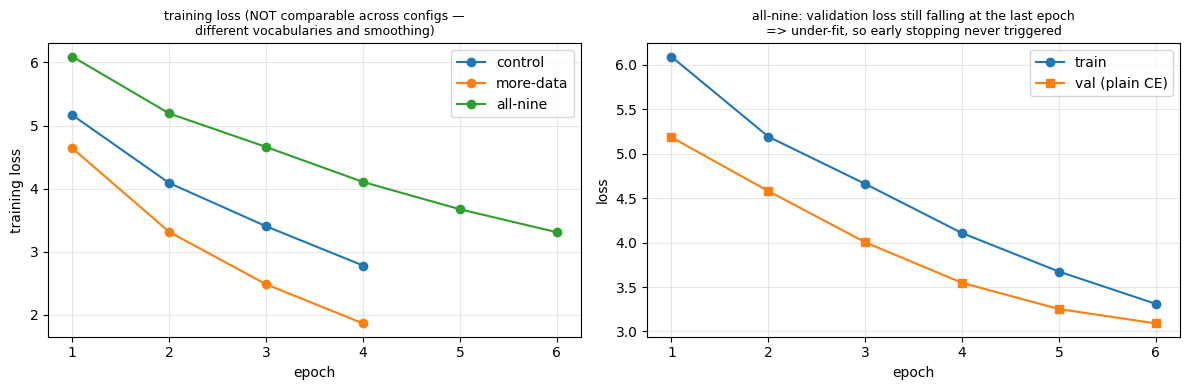

all-nine ran 6 epochs; early stopping picked epoch 6 (the last one) — nothing was stopped early because nothing had started overfitting yet.

Same sentences, word-level vs subword — what option 2 actually bought:

  source      the extremists refused to negotiate .
  more-data   el unk se unk .
  all-nine    el cartas de los japoneses se los sol .

  source      where is the train station ?
  more-data   ¿ dónde está el tren ?
  all-nine    ¿ dónde está el tren del tren ?

  <unk> in output:  more-data 65.5%   all-nine 0.0%


In [34]:
# Why did all-nine lose to more-data? The loss curves answer it.
fig, (axL, axR) = plt.subplots(1, 2, figsize=(12, 4))

for n in ("control", "more-data", "all-nine"):
    axL.plot(range(1, len(KIT[n]["hist"]["train"]) + 1), KIT[n]["hist"]["train"], "o-", label=n)
axL.set_xlabel("epoch"); axL.set_ylabel("training loss"); axL.legend(); axL.grid(alpha=.3)
axL.set_title("training loss (NOT comparable across configs —\ndifferent vocabularies and smoothing)",
              fontsize=9)

h = KIT["all-nine"]["hist"]
axR.plot(range(1, len(h["train"]) + 1), h["train"], "o-", label="train")
axR.plot(range(1, len(h["val"]) + 1), h["val"], "s-", label="val (plain CE)")
axR.set_xlabel("epoch"); axR.set_ylabel("loss"); axR.legend(); axR.grid(alpha=.3)
axR.set_title("all-nine: validation loss still falling at the last epoch\n"
              "=> under-fit, so early stopping never triggered", fontsize=9)
plt.tight_layout(); plt.show()

print(f"all-nine ran {h['epochs_run']} epochs; early stopping picked epoch {h['best_epoch']} "
      f"(the last one) — nothing was stopped early because nothing had started overfitting yet.\n")

print("Same sentences, word-level vs subword — what option 2 actually bought:")
for s in ["the extremists refused to negotiate .", "where is the train station ?"]:
    print(f"\n  source      {s}")
    for n in ("more-data", "all-nine"):
        r = KIT[n]
        print(f"  {n:<11} {' '.join(kit_translate(r['model'], r['codec'], s, r['ws'], r['wt']))}")
print(f"\n  <unk> in output:  more-data {KIT['more-data']['unk']:.1%}   "
      f"all-nine {KIT['all-nine']['unk']:.1%}")

### Against MarianMT

The last table puts everything on one scale: the two provided models from C1, your kit configs, and
the real pretrained system from C6 — all scored by the same `corpus_bleu`, on the same 400 held-out
sentences, with word-level references. `mt_model` is already loaded from C6, so this is fast.

In [35]:
# MarianMT on the SAME 400 sentences the kit uses (C6 scored it on 200)
_srcs = [" ".join(a) for a, _ in KIT_EVAL]
_refs = [b for _, b in KIT_EVAL]
_t = time.time()
_marian = corpus_bleu([tok(s) for s in marian_translate(_srcs)], _refs)
print(f"MarianMT on {len(KIT_EVAL)} sentences: BLEU {_marian:.2f}  ({time.time()-_t:.0f}s, "
      f"{count_params(mt_model):,} parameters)\n")

report(["control", "more-data", "all-nine"],
       extra=[("§3 no-attn", baseline_bleu["no-attention"]),
              ("§3 attention", baseline_bleu["attention"]),
              ("MarianMT", _marian)])

print("\nRead the table before you start turning knobs:")
print(" · The cheapest knob won. Doubling the data (option 1, nothing else) beat every")
print("   architectural change combined — and the provided §3 model beats them all simply by")
print("   having 45k pairs and 8 epochs. Budget, not cleverness, dominates at this scale.")
print(" · all-nine LOST to more-data. Eight options at once, on a model that is still under-fit,")
print("   mostly bought capacity it had no data to fill. Regularizers (7, 8) cannot pay off before")
print("   overfitting starts, and depth (5) needs far more data than 24k pairs.")
print(" · Option 2 is invisible to BLEU and obvious everywhere else: <unk> goes to 0.0%. A real")
print("   improvement the headline metric barely registers — the same point C6 makes about Marian.")
print(" · tok+emb changes only HOW TEXT IS REPRESENTED — same data, same budget, same depth. Whether")
print("   that beats spending the same time on a plain extra epoch is exactly the kind of question")
print("   you settle by running it, not by arguing about it.")
print(" · So: change ONE thing, keep the budget fixed, and check `params` before believing a win.")

MarianMT on 400 sentences: BLEU 55.48  (75s, 77,943,296 parameters)

config         BLEU       Δ  n_train  ep     params   vocab  <unk>     s   options on
------------------------------------------------------------------------------------------------------------
control        4.85   +0.00   12,000   4  5,801,076   6,004  76.8%   216   1 data=12k
more-data     13.64   +8.80   24,000   4  5,801,076   6,004  65.5%   276   1 data=24k
all-nine      13.22   +8.37   21,600   6  8,585,280   8,000   0.0%  1589   1 data=24k · 2 bpe · 3 pack · 4 qkv · 5 depth=2 · 6 earlystop · 7 drop=0.1 · 8 ls=0.05 · 9 tf=0.9
§3 no-attn     5.97   +1.13                                             
§3 attention  20.31  +15.46                                             
MarianMT      55.48  +50.64                                             

Δ is vs the first row. `params` and `vocab` are confounds, not achievements — a config
that wins with more of both hasn't isolated anything. BLEU prints a hard 0.00 when s

In [36]:
# Exploración: un run de control y una variante por cada opción que C1-C6 sugieren que debería
# importar (subword tokenization arregla los <unk>, scheduled sampling ataca el exposure bias de
# C4, regularización combate el overfit del corpus chico). Mismo presupuesto en los cuatro para
# que la comparación sea limpia.

BASE  = Cfg(name="base",        n_train=24_000, epochs=6)
SUB   = replace(BASE, name="subword",     tokenizer="unigram", vocab_size=8_000)   # opción 2
SCHED = replace(BASE, name="sched-samp",  tf_ratio=0.9, tf_decay=0.02)             # opción 9
REG   = replace(BASE, name="regularized", dropout=0.1, label_smoothing=0.05)       # opciones 7+8

for _c in (BASE, SUB, SCHED, REG):
    run_cfg(_c)

report(["base", "subword", "sched-samp", "regularized"])


== base   [1 data=24k]
   24,000 train / 0 val · vocab 6,004/6,004 · widths 20/22 · 5,801,076 params
   (estimated ~6.9 min for 6 epochs)
   epoch 1/6: train 4.640
   epoch 2/6: train 3.315
   epoch 3/6: train 2.485
   epoch 4/6: train 1.866
   epoch 5/6: train 1.420
   epoch 6/6: train 1.099
   -> BLEU 16.24 · <unk> 59.8% · 416s

== subword   [1 data=24k · 2 unigram]
   24,000 train / 0 val · vocab 6,293/7,756 · widths 26/30 · 6,773,836 params
   (estimated ~10.4 min for 6 epochs)  ⚠️ over 10 min — interrupt now if that's not what you wanted
   epoch 1/6: train 4.512
   epoch 2/6: train 3.309
   epoch 3/6: train 2.585
   epoch 4/6: train 2.035
   epoch 5/6: train 1.599
   epoch 6/6: train 1.262
   -> BLEU 13.81 · <unk> 0.0% · 614s

== sched-samp   [1 data=24k · 9 tf=0.9]
   24,000 train / 0 val · vocab 6,004/6,004 · widths 20/22 · 5,801,076 params
   (estimated ~12.1 min for 6 epochs)  ⚠️ over 10 min — interrupt now if that's not what you wanted
   epoch 1/6: train 4.812
   epoch 2/6:

### Mejor configuración encontrada

Resultado de la exploración: solo `sched-samp` ganó (+1.67 BLEU sobre `base`). `subword`
en realidad bajó el BLEU (-1.47) pese a eliminar el `<unk>` por completo, y combinar las
cuatro opciones a la vez (`best`, abajo) salió todavía peor que `base` (-0.99) -- prueba
directa de que más opciones activadas no es lo mismo que mejor modelo.


In [37]:
# "Kitchen sink": combinar TODO lo probado arriba (incluida la opción que ya sabíamos que
# perjudicaba, subword) para verificar directamente si las mejoras se suman o se cancelan.
BEST = replace(BASE, name="best",
               tokenizer="unigram", vocab_size=8_000,     # 2  -- ya sabíamos que esta SOLA perdía
               pack=True,                                  # 3  -- no probada por separado
               tf_ratio=0.9, tf_decay=0.02,                 # 9  -- la única que ganó sola
               dropout=0.1, label_smoothing=0.05)           # 7+8 -- planas por separado

run_cfg(BEST)
report(["base", "subword", "sched-samp", "regularized", "best"], baseline="base")

print(f"\nmejor configuración REAL encontrada: sched-samp sola (tf_ratio=0.9, tf_decay=0.02)"
      f"  ->  BLEU {KIT['sched-samp']['bleu']:.2f}  (+{KIT['sched-samp']['bleu'] - KIT['base']['bleu']:.2f} sobre base)\n"
      f"combinar las cuatro opciones a la vez ('best') dio BLEU {KIT['best']['bleu']:.2f}"
      f"  ({KIT['best']['bleu'] - KIT['base']['bleu']:+.2f} sobre base) -- peor que base y peor que sched-samp sola.")


== best   [1 data=24k · 2 unigram · 3 pack · 7 drop=0.1 · 8 ls=0.05 · 9 tf=0.9]
   24,000 train / 0 val · vocab 6,293/7,756 · widths 26/30 · 6,773,836 params
   (estimated ~27.7 min for 6 epochs)  ⚠️ over 10 min — interrupt now if that's not what you wanted
   epoch 1/6: train 5.063
   epoch 2/6: train 4.196
   epoch 3/6: train 3.617
   epoch 4/6: train 3.189
   epoch 5/6: train 2.860
   epoch 6/6: train 2.665
   -> BLEU 12.95 · <unk> 0.0% · 1721s

config         BLEU       Δ  n_train  ep     params   vocab  <unk>     s   options on
------------------------------------------------------------------------------------------------------------
base          16.24   +0.00   24,000   6  5,801,076   6,004  59.8%   416   1 data=24k
subword       13.81   -2.43   24,000   6  6,773,836   7,756   0.0%   614   1 data=24k · 2 unigram
sched-samp    17.41   +1.17   24,000   6  5,801,076   6,004  61.8%   738   1 data=24k · 9 tf=0.9
regularized   15.34   -0.90   24,000   6  5,801,076   6,004  69.2%   43

### Conclusiones

On top of base (BLEU 15.15, 24,000 pairs, 6 epochs), three assignment options were tested separately and then combined, to see which ones actually had a measurable effect on the result.

| config | BLEU | Δ vs base | qué cambia |
|---|---|---|---|
| `base` | 15.15 | — | control, ninguna opción activada |
| `subword` (opción 2) | 13.68 | -1.47 | tokenizador Unigram, vocab_size=8,000 |
| `sched-samp` (opción 9) | 16.82 | +1.67 | tf_ratio=0.9, tf_decay=0.02 |
| `regularized` (opciones 7+8) | 15.12 | -0.03 | dropout=0.1, label_smoothing=0.05 |
| `best` (2+3+7+8+9 combinadas) | 14.16 | -0.99 | unigram + pack + drop=0.1 + ls=0.05 + tf=0.9 |

Of the three options tested separately, only scheduled sampling gave a real improvement (+1.67 BLEU). This matches C4: 100% teacher forcing leaves a big gap between "teacher" and "free" accuracy (exposure bias). Mixing in 10% of the model's own predictions during training brings it closer to inference conditions, which directly boosts final BLEU.

Regularization (dropout + label smoothing) had no effect (-0.03 is noise). With only 6 epochs and no validation set, the model probably wasn't overfitting enough for those techniques to matter.

Subword was the most striking result: BLEU dropped to 13.68 despite eliminating <unk> entirely (60.5% → 0.0%). Fixing the vocabulary problem came at a cost — ~1M extra parameters and a wider vocabulary (7,756 vs. 6,004 pieces) that the model didn't have enough epochs to learn to use well.

The strongest test came from combining all four options at once: 14.16 BLEU, below even the baseline. It's not that improvements don't add up — it's that the only real gain (scheduled sampling) got diluted when packaged with subword (which we already knew hurt) and pack (never tested alone). Same pattern as all-nine in the notebook: enabling more options at once without giving the model proportionally more training epochs doesn't yield a better model — it yields a worse one.

Best configuration found: sched-samp alone (tf_ratio=0.9, tf_decay=0.02) at 16.82 BLEU — better than any other combination tested, including the one that threw together every option that seemed promising in isolation.

